In [1]:
import sys
from tqdm import tqdm
import numpy as np
import os
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")
import torch
import torch.nn as nn
import torch.nn.functional as F
import ast
from torch.utils.data import Dataset
import time
from torch.utils.data import DataLoader
import json
import argparse
from sklearn.model_selection import train_test_split
from torch import optim
from sklearn.calibration import LabelEncoder
import pandas as pd
import numpy as np
import os
# import seaborn as sns
from tqdm.auto import tqdm
import warnings
from sklearn.preprocessing import OneHotEncoder
import gc
import pickle
from sklearn.decomposition import TruncatedSVD
import glob
from torch.nn.utils.rnn import pad_sequence
import math
DATA_PATH = r"C:\Coding\mabe\data"
CACHE_PATH = r"C:\Coding\mabe\MABe_2022_TVAE\cache"
SPECIAL_VALUE = -99999.0
CHUNK_SIZE = 1000
SUB_SEQ_LENGTH = 21
SLIDING_WINDOW = 1
ALPHA = 15

True
NVIDIA GeForce RTX 4070 SUPER


In [2]:
import pandas as pd

# Your DataFrame (assume it's called df)

# Step 1: Define the priority mapping
priority_map = {
    'top_left': [
        ('ear_left', 1),
        ('forepaw_left', 2),
        ('headpiece_bottombackleft', 3),
        ('headpiece_bottomfrontleft', 4),
        ('headpiece_topbackleft', 5),
        ('headpiece_topfrontleft', 6),
        ('lateral_left', 7),
    ],
    'top_right': [
        ('ear_right', 1),
        ('forepaw_right', 2),
        ('headpiece_bottombackright', 3),
        ('headpiece_bottomfrontright', 4),
        ('headpiece_topbackright', 5),
        ('headpiece_topfrontright', 6),
        ('lateral_right', 7),
    ],
    'bottom': [
        ('tail_base', 1),
        ('tail_midpoint', 2),
        ('tail_middle_1', 3),
        ('tail_middle_2', 4),
        ('hindpaw_left', 5),
        ('hindpaw_right', 6),
        ('hip_left', 7),
        ('hip_right', 8),
        ('tail_tip', 9),
    ],
    'top_center': [
        ('nose', 1),
        ('head', 2),
        ('neck', 3),
        ('body_center', 4),
    ],
}

# Flatten for quick lookup
bodypart_to_target = {}
for target, parts in priority_map.items():
    for part, priority in parts:
        bodypart_to_target[part] = (target, priority)

# Step 2: Filter only relevant bodyparts (ignore 'spine_1', 'spine_2', etc.)
def reassign_points(path, start, stop):
    df = pd.read_parquet(path)
    # df['video_frame'] = df['video_frame'] - df['video_frame'].iloc[0]
    # print(f"shape before: {df.shape}")
    # Filter early: only keep frames within the desired range
    df = df[(df['video_frame'] >= start) & (df['video_frame'] < stop)]
    # print(f"shape after: {df.shape}")

    df['assignment'] = df['bodypart'].map(bodypart_to_target)

    # Drop rows with no assignment
    df = df.dropna(subset=['assignment'])

    # Add target and priority columns
    df[['target', 'priority']] = pd.DataFrame(df['assignment'].tolist(), index=df.index)

    # Keep only the highest priority (lowest number) per group, per target
    df_sorted = df.sort_values(by=['video_frame', 'mouse_id', 'target', 'priority'])
    df_deduped = df_sorted.drop_duplicates(subset=['video_frame', 'mouse_id', 'target'], keep='first')

    # Pivot to get final structure
    df_final = df_deduped.pivot_table(
        index=['video_frame', 'mouse_id'],
        columns='target',
        values=['x', 'y']
    )

    # Flatten MultiIndex columns
    df_final.columns = [f'{col[1]}_{col[0]}' for col in df_final.columns]

    # Reset index but preserve video_frame as-is
    df_final = df_final.reset_index()  # 'video_frame' stays intact
    # print(df_final.shape)

    return df_final



In [3]:
# body_parts = [
#     "ear_left",
#     "ear_right",
#     "tail_base",
#     "nose",
#     "neck",
#     "body_center",
#     "tail_tip",
#     "tail_midpoint",
#     "forepaw_left",
#     "forepaw_right",
#     "hindpaw_left",
#     "hindpaw_right",
#     "hip_left",
#     "hip_right",
#     "lateral_left",
#     "lateral_right",
#     "spine_1",
#     "spine_2",
#     "tail_middle_1",
#     "tail_middle_2",
#     "head",
#     "headpiece_bottombackleft",
#     "headpiece_bottombackright",
#     "headpiece_bottomfrontleft",
#     "headpiece_bottomfrontright",
#     "headpiece_topbackleft",
#     "headpiece_topbackright",
#     "headpiece_topfrontleft",
#     "headpiece_topfrontright"
# ]
body_parts = ['top_center', 'top_left', 'top_right', 'bottom']
len(body_parts)

all_cols = []
for i in range(1, 5):
    for part in body_parts:
        for j in ['x', 'y']:
            all_cols.append(f"mouse_{i}_{part}_{j}")

len(all_cols)

32

In [4]:
def rotate_keypoints(df: pd.DataFrame, width: int, height: int, angle: int) -> pd.DataFrame:
    if angle == 0:
        return df
    if angle not in [90, 180, 270]:
        raise ValueError("Angle must be one of: 90, 180, or 270 degrees")

    df_rot = df.copy()

    # Get all unique keypoint prefixes (like 'mouse_1_ear_left', 'mouse_2_nose', etc.)
    base_names = sorted({col.rsplit('_', 1)[0] for col in df.columns})

    for name in base_names:
        x_col = f"{name}_x"
        y_col = f"{name}_y"

        x = df[x_col]
        y = df[y_col]

        if angle == 90:
            x_new = height - y - 1
            y_new = x
        elif angle == 180:
            x_new = width - x - 1
            y_new = height - y - 1
        elif angle == 270:
            x_new = y
            y_new = width - x - 1

        df_rot[x_col] = x_new
        df_rot[y_col] = y_new

    return df_rot

In [5]:
def load_and_process_video(video_id, lab_id, start, end, width, height, angle, data_path=DATA_PATH):
    # print(f"doing from {start} to {end}")
    tracking_path = os.path.join(data_path, 'train_tracking', lab_id, f'{video_id}.parquet')
    if not os.path.exists(tracking_path):
        return None
    df = reassign_points(tracking_path, start, end)
    df.set_index(['video_frame', 'mouse_id'], inplace=True)

    # Step 2: Flatten the structure by pivoting mouse_id into columns
    df_wide = df.unstack(level='mouse_id')

    # Step 3: Flatten the MultiIndex column names
    df_wide.columns = [f'mouse_{mouse_id}_{col}' for col, mouse_id in df_wide.columns]

    df_wide = df_wide.reindex(columns=all_cols)
    df_wide = rotate_keypoints(df_wide, width, height, angle)

    # For debugging
    # print(f"df long cols {df_wide.columns}")
    # print(f"df long {df_wide.head}")
    # print(f"df wide shape {df_wide.shape}")
    return df_wide

CORE_BODYPARTS = ['top_center', 'top_left', 'top_right', 'bottom']
def create_advanced_features(df_wide):
    """
    Creates a rich set of kinematic, interaction, and postural features.
    """
    # Start with a copy of the original data
    features_df = df_wide.copy()
    
    mouse_ids = [1, 2, 3, 4] # Assuming up to 4 mice
    
    # --- 1. Kinematic Features (Speeds) ---
    for mid in mouse_ids:
        for part in CORE_BODYPARTS:
            col_x, col_y = f'mouse_{mid}_{part}_x', f'mouse_{mid}_{part}_y'
            if col_x in features_df.columns:
                delta_x = features_df[col_x].diff()
                delta_y = features_df[col_y].diff()
                features_df[f'mouse{mid}_{part}_speed'] = np.sqrt(delta_x**2 + delta_y**2)

    # --- 2. Postural Features (Body Elongation) ---
    for mid in mouse_ids:
        nose_x, nose_y = f'mouse_{mid}_top_center_x', f'mouse_{mid}_top_center_y'
        tail_x, tail_y = f'mouse_{mid}_bottom_x', f'mouse{mid}_bottom_y'
        if all(c in features_df.columns for c in [nose_x, nose_y, tail_x, tail_y]):
            features_df[f'mouse{mid}_elongation'] = np.sqrt(
                (features_df[nose_x] - features_df[tail_x])**2 + 
                (features_df[nose_y] - features_df[tail_y])**2
            )

    # --- 3. Interaction Features (Distances) ---
    mouse_pairs = [(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
    for m1, m2 in mouse_pairs:
        for part1 in CORE_BODYPARTS:
            for part2 in CORE_BODYPARTS:
                p1_x, p1_y = f'mouse{m1}_{part1}_x', f'mouse{m1}_{part1}_y'
                p2_x, p2_y = f'mouse{m2}_{part2}_x', f'mouse{m2}_{part2}_y'
                if all(c in features_df.columns for c in [p1_x, p1_y, p2_x, p2_y]):
                    features_df[f'dist_m{m1}{part1}_m{m2}{part2}'] = np.sqrt(
                        (features_df[p1_x] - features_df[p2_x])**2 + 
                        (features_df[p1_y] - features_df[p2_y])**2
                    )
                    
    # Drop the original coordinate columns to force the model to use our new features
    features_df = features_df.drop(columns=df_wide.columns)
    
    return features_df

def create_hybrid_features(df_wide):
    engineered_features = create_advanced_features(df_wide.copy())
    
    hybrid_features = pd.concat([df_wide, engineered_features], axis=1)
    return hybrid_features

In [6]:
def normalize(data, FRAME_WIDTH_TOP, FRAME_HEIGHT_TOP):
    """Normalize coordinate data (NumPy array or DataFrame)."""
    is_df = isinstance(data, pd.DataFrame)
    values = data.values if is_df else data

    state_dim = values.shape[1] // 2
    shift = np.array([FRAME_WIDTH_TOP / 2, FRAME_HEIGHT_TOP / 2] * state_dim)
    scale = np.array([FRAME_WIDTH_TOP / 2, FRAME_HEIGHT_TOP / 2] * state_dim)

    normalized = (values - shift) / scale
    normalized = np.where(normalized < 0, -1, normalized)

    if is_df:
        return pd.DataFrame(normalized, columns=data.columns, index=data.index)
    else:
        return normalized

def unnormalize(data, FRAME_WIDTH_TOP, FRAME_HEIGHT_TOP):
    """
    Undo normalization of coordinate data.
    Accepts NumPy arrays, Pandas DataFrames, or PyTorch tensors.
    Expects data in the format: [batch_size, x1, y1, x2, y2, ..., xn, yn]
    """

    # Convert torch tensor to NumPy array
    if torch.is_tensor(data):
        data = data.detach().cpu().numpy()

    is_df = isinstance(data, pd.DataFrame)
    values = data.values if is_df else data

    state_dim = values.shape[1] // 2

    x_shift = FRAME_WIDTH_TOP / 2
    y_shift = FRAME_HEIGHT_TOP / 2
    x_scale = FRAME_WIDTH_TOP / 2
    y_scale = FRAME_HEIGHT_TOP / 2

    # Unnormalize x and y coordinates separately
    values[:, ::2] = values[:, ::2] * x_scale + x_shift  # x coordinates
    values[:, 1::2] = values[:, 1::2] * y_scale + y_shift  # y coordinates

    # Return in original format
    if is_df:
        return pd.DataFrame(values, columns=data.columns, index=data.index)
    else:
        return values  # shape remains [batch_size, state_dim * 2]


def rotate(data, center_index):
    # data shape is num_seq x 3 x 10 x 2
    
    data = data.reshape(data.shape[0], 4, 29 ,2)
    mice = [data[:,i,:10,:] for i in range(3)]
    data = np.concatenate(mice, axis=0)

    del mice
    gc.collect()

    mouse_center = data[:, center_index, :]
    centered_data = data - mouse_center[:, np.newaxis, :]

	# Rotate such that keypoints 3 and 6 are parallel with the y axis
    mouse_rotation = np.arctan2(
		data[:, 3, 0] - data[:, 9, 0], data[:, 3, 1] - data[:, 9, 1])

    R = (np.array([[np.cos(mouse_rotation), -np.sin(mouse_rotation)],
				   [np.sin(mouse_rotation),  np.cos(mouse_rotation)]]).transpose((2, 0, 1)))

	# Encode mouse rotation as sine and cosine
    mouse_rotation = np.concatenate([np.sin(mouse_rotation)[:, np.newaxis], np.cos(
		mouse_rotation)[:, np.newaxis]], axis=-1)

    centered_data = np.matmul(R, centered_data.transpose(0, 2, 1))
    centered_data = centered_data.transpose((0, 2, 1))
    centered_data = centered_data.reshape((-1, 20))

    return centered_data, mouse_center, mouse_rotation

In [7]:
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))

video_paths = []
for _, row in df.iterrows():
    video_paths.append([row['video_id'], row['lab_id'], row['video_width_pix'], row['video_height_pix']])

In [8]:
# import pandas as pd
# import numpy as np

# def apply_svd_to_video_parquet(video_path, svd, mean_pose):
#     df = pd.read_parquet(video_path)

#     vec_seq = df.to_numpy()  # shape: (n_frames, n_keypoints * 2)

#     normalized = normalize(vec_seq)

#     centered = normalized - mean_pose

#     projected = centered @ svd.T  # shape: (n_frames, svd_dim)

#     return projected


In [9]:
class MABEDataset(Dataset):
    def __init__(self, path, cache_path, train=True):
        self.path = path
        self.train_df = pd.read_csv(os.path.join(path, "train.csv"))
        self.all_files = []
        self.pairs = []
        self.train = train
        for root, dirs, files in os.walk(os.path.join(path, 'train_tracking')):
            for file in files:
                full_path = os.path.join(root, file)
                self.all_files.append(full_path)

        for _, row in self.train_df.iterrows():
            if os.path.join(self.path, 'train_tracking', row['lab_id'], str(row['video_id']) + ".parquet") not in self.all_files:
                continue
            lab_id = str(row['lab_id'])
            self.pairs.append([row['video_id'], lab_id, row['video_width_pix'], row['video_height_pix']])

        print(f"{len(self.pairs)} unique videos")
        self.sub_seq_length = 21
        self.sliding_window = 1
        with open('./svd.pkl', 'rb') as f:
            self.svd = pickle.load(f)

        with open('./mean.pkl', 'rb') as f:
            self.mean = pickle.load(f)
        self.test_prop = 0.20
        self.cache_path = cache_path

        # === Start of exclusion code ===
        # Filter rows where lab_id does NOT start with "mabe" (case insensitive)
        # if train:
        #     eligible_rows = self.train_df[~self.train_df['lab_id'].str.lower().str.startswith('mabe')]

        #     # Set a fixed seed for reproducibility
        #     rng = np.random.default_rng(seed=42)  # Using numpy's Generator for randomness

        #     # Randomly select 100 indices from eligible rows without replacement
        #     exclude_indices = rng.choice(eligible_rows.index, size=160, replace=False)

        #     # Get the filenames of the excluded files: construct the parquet filename
        #     excluded_files = []
        #     for idx in exclude_indices:
        #         row = self.train_df.loc[idx]
        #         filename = os.path.join(self.path, 'train_tracking', row['lab_id'], f"{row['video_id']}.parquet")
        #         excluded_files.append(filename)

        #     # Save excluded files list to a pickle
        #     with open(os.path.join(self.cache_path, 'excluded_files.pkl'), 'wb') as f:
        #         pickle.dump(excluded_files, f)

        #     print(f"Excluded {len(excluded_files)} files saved to excluded_files.pkl")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        # if os.path.isfile(os.path.join(self.cache_path, f"{self.pairs[idx][0]}_{self.pairs[idx][1]}.pt")):
        #     loaded = torch.load(os.path.join(self.cache_path, f"{self.pairs[idx][0]}_{self.pairs[idx][1]}.pt"))
        #     loaded = loaded['sub_seqs']

        #     test_len = int(len(loaded) * self.test_prop)

        #     if self.train:
        #         loaded = loaded[test_len:]
        #     else:
        #         loaded = loaded[:test_len]
        #     states = loaded  # shape: [num_seqs, seq_len, state_dim]
        #     actions = loaded[:, 1:] - states[:, :-1]  # compute differences
        #     return torch.from_numpy(states).float(), torch.from_numpy(actions).float()
        df = load_and_process_video(self.pairs[idx][0], self.pairs[idx][1])
        width = self.pairs[idx][2]
        height = self.pairs[idx][3]
        vec_seq = df.to_numpy()
        vec_seq = np.where(np.isnan(vec_seq), -1, vec_seq)
        vec_seq = normalize(vec_seq, width, height)

        # Pad and slice into subsequences
        vec_seq = vec_seq.reshape(vec_seq.shape[0], -1)
        pad_vec = np.pad(
            vec_seq,
            ((self.sub_seq_length // 2, self.sub_seq_length - 1 - self.sub_seq_length // 2), (0, 0)),
            mode='edge'
        )

        sub_seqs = np.stack(
            [pad_vec[j:len(pad_vec) + j - self.sub_seq_length + 1:self.sliding_window] for j in range(self.sub_seq_length)],
            axis=1
        )

        # tensors = {
        #     'sub_seqs': sub_seqs
        # }
        # # Save to cache folder so that entire processing does not need to be done every time
        # torch.save(tensors, os.path.join(self.cache_path, f"{self.pairs[idx][0]}_{self.pairs[idx][1]}.pt"))

        test_len = int(len(sub_seqs) * self.test_prop)
        if self.train:
            sub_seqs = sub_seqs[test_len:]
        else:
            sub_seqs = sub_seqs[:test_len]

        states = sub_seqs  # shape: [num_seqs, seq_len, state_dim]
        actions = states[:, 1:] - states[:, :-1]  # compute differences
        # print(f"states {states.shape}")
        # print(f"actions {actions.shape}")

        # Return as tuple
        return torch.from_numpy(states).float(), torch.from_numpy(actions).float()

In [10]:
# Example model arguments
model_config = { 
    "name": "tvae",
    "z_dim": 32,      # Dimensionality of the posterior / embedding
    "h_dim": 256,     # Number of units to use in the fully-connected layers in the encoder and decoder
    "rnn_dim": 256,   # Number of units to use in the recurrent encoder and decoder
    "num_layers": 1,  # Number of layers to use in the recurrent encoder and decoder 
    "state_dim": 32,  # Dimensionality of the input states - we are only embedding single fly features for now
    "action_dim": 32  # Dimensionality of the input actions
}

# Example training arguments
train_config = { 
    "batch_size": 8,          # Batch size to use during training - higher = faster, but more GPU utilization
    "num_epochs_til_val": 10,   # Checkpoints will be saved to ./checkpoints/{project_name}/ every num_epochs_til_val epochs 
    "learning_rate": 0.0002,    # Learning rate for the optimizer to use
    "num_epochs": 300,          # Number of epochs to use
    "clip": 10,                 # Higher means potentially faster but more unstable training
    "project_name": 'test_mouse_jupyter_notebook',  # All checkpoints and loss logs will be saved to ./checkpoints/project_name/
    "start_model_path": r"C:\Coding\mabe\MABe_2022_TVAE\checkpoints\test_mouse_jupyter_notebook\60.pt",
    "start_epoch": 60
}

In [11]:
data_train = MABEDataset(DATA_PATH, CACHE_PATH, True)
data_test = MABEDataset(DATA_PATH, CACHE_PATH, False)


def collate_fn(batch):
    states, actions = zip(*batch)  # Each is a list of tensors with shape (seq_len, sub_seq_len, feat_dim)

    # Convert to tensors
    states = [torch.tensor(s) for s in states]
    actions = [torch.tensor(a) for a in actions]

    # Find the minimum sequence length across the batch
    min_seq_len = min(s.shape[0] for s in states)

    # Truncate all sequences to the minimum length
    truncated_states = torch.stack([s[:min_seq_len] for s in states], dim=0)
    truncated_actions = torch.stack([a[:min_seq_len] for a in actions], dim=0)

    # Result shape: (batch_size, min_seq_len, sub_seq_len, feat_dim)
    return truncated_states, truncated_actions

8789 unique videos
8789 unique videos


In [12]:
from datasets import load_dataset

# Device configurations
device = torch.device('cuda:0')

data_config = { 
    'name': 'mouse_v1',
    'data_train': data_train,
    'data_test': data_test,
    'device': device,
}   

train_loader = DataLoader(
                data_train,
                batch_size=train_config['batch_size'],
                shuffle = True,
                collate_fn=collate_fn,
                # num_workers=4,
)

test_loader = DataLoader(
                data_test,
                batch_size=train_config['batch_size'],
                shuffle = True,
                collate_fn=collate_fn,
                # num_workers=4,
)

In [13]:
class Distribution(nn.Module):

    def __init__(self):
        super(Distribution, self).__init__()

    def sample(self):
        raise NotImplementedError

    def log_prob(self, value):
        raise NotImplementedError
    
class LogEntry(object):

    def __init__(self, init_losses=[], init_metrics=[]):
        assert isinstance(init_losses, list)
        self._losses = {}
        for key in init_losses:
            self._losses[key] = 0

        assert isinstance(init_metrics, list)
        self._metrics = {}
        for key in init_metrics:
            self._metrics[key] = 0
    
    def __repr__(self):
        return str(self)

    def __str__(self):
        loss_str = ''
        for key, value in self._losses.items():
            if value != 0:
                loss_str += ' | {}: {:.4f}'.format(key, value)
        loss_str += ' | {}: {:.4f}'.format('Total', sum(self._losses.values()))

        metric_str = ''
        for key, value in self._metrics.items():
            if value != 0:
                metric_str += ' | {}: {:.4f}'.format(key, value)

        out = ''
        if len(loss_str) > 0:
            out += 'Losses\t{}\n'.format(loss_str)
        if len(metric_str) > 0:
            out += 'Metrics\t{}\n'.format(metric_str)

        if len(out) > 0:
            out = out[:-1]

        return out

    @property
    def losses(self):
        return self._losses
    
    @property
    def metrics(self):
        return self._metrics

    def clear(self):
        self._losses = {}
        self._metrics = {}

    def reset(self):
        for key in self._losses:
            self._losses[key] = 0
        for key in self._metrics:
            self._metrics[key] = 0

    def add_loss(self, key):
        if key not in self._losses:
            self._losses[key] = 0

    def add_metric(self, key):
        if key not in self._metrics:
            self._metrics[key] = 0

    def itemize(self):
        for key, value in self._losses.items():
            if isinstance(value, torch.Tensor):
                self._losses[key] = value.item()

        for key, value in self._metrics.items():
            if isinstance(value, torch.Tensor):
                self._metrics[key] = value.item()

    def absorb(self, other_log):
        assert isinstance(other_log, LogEntry)

        for key, value in other_log.losses.items():
            if key in self._losses:
                self._losses[key] += value
            else:
                self._losses[key] = value

        for key, value in other_log.metrics.items():
            if key in self._metrics:
                self._metrics[key] += value
            else:
                self._metrics[key] = value

    def average(self, N):
        for key in self._losses:
            self._losses[key] /= N

        for key in self._metrics:
            self._metrics[key] /= N

    def to_dict(self):
        return { 'losses' : self._losses, 'metrics' : self.metrics }

class Normal(Distribution):

    logvar_min = -16
    logvar_max = 16

    def __init__(self, mean, logvar):
        super().__init__()

        self.mean = mean
        self.logvar = torch.clamp(logvar, self.logvar_min, self.logvar_max)

    def sample(self, temperature=1.0):
        std = torch.exp(self.logvar / 2)
        eps = torch.randn_like(std)
        return self.mean + eps * std * temperature

    def log_prob(self, value):
        pi = torch.FloatTensor([math.pi]).to(value.device)
        nll_element = (value - self.mean).pow(2) / \
            torch.exp(self.logvar) + self.logvar + torch.log(2 * pi)
        return -0.5 * torch.sum(nll_element)

    @staticmethod
    def kl_divergence(normal_1, normal_2=None, free_bits=0.0):
        '''
        Computes the kl-divergence between two normal distributions.

        Args:
            normal_1 (Normal): first normal distribution
            normal_2 (Normal): second normal distribution (assume standard normal if not provided)
        '''

        assert isinstance(normal_1, Normal)
        mean_1, logvar_1 = normal_1.mean, normal_1.logvar

        if normal_2 is not None:
            assert isinstance(normal_2, Normal)
            mean_2, logvar_2 = normal_2.mean, normal_2.logvar

            kld_elements = 0.5 * (logvar_2 - logvar_1 +
                                  (torch.exp(logvar_1) + (mean_1 - mean_2).pow(2)) /
                                  torch.exp(logvar_2) - 1)
        else:
            kld_elements = -0.5 * \
                (1 + logvar_1 - mean_1.pow(2) - torch.exp(logvar_1))

        # Prevent posterior collapse with free bits
        if free_bits > 0.0:
            _lambda = free_bits * \
                torch.ones(kld_elements.size()).to(kld_elements.device)
            kld_elements = torch.max(kld_elements, _lambda)

        kld = torch.sum(kld_elements, dim=-1)

        return kld

class TVAE(nn.Module):
    """
    This is a modified version of the BaseSequentialModel class created by 
    Jennifer Sun located at https://github.com/neuroethology/TREBA/

    Modifications made are to include only the Trajectory Variational Autoencoder
    model i.e. there is no decoding into programs, just the original trajectory.
    """
    model_args = []
    requires_labels = False
    is_recurrent = True

    def __init__(self, model_config):
        super().__init__()

        if 'recurrent' in model_config:
            self.is_recurrent = model_config['recurrent']

        # Assert rnn_dim and num_layers are defined if model is recurrent
        if self.is_recurrent:
            if 'rnn_dim' not in self.model_args:
                self.model_args.append('rnn_dim') 
            if 'num_layers' not in self.model_args:
                self.model_args.append('num_layers')

        # Assert label_dim is defined if model requires labels
        if self.requires_labels and 'label_dim' not in self.model_args:
            self.model_args.append('label_dim')

        # Check for missing arguments
        missing_args = set(self.model_args) - set(model_config)
        assert len(missing_args) == 0, 'model_config is missing these arguments:\n\t{}'.format(', '.join(missing_args))
        
        self.config = model_config
        self.log = LogEntry()
        self.stage = 0 # some models have multi-stage training            

        self._construct_model()
        self._define_losses()

        if self.is_recurrent:
            assert hasattr(self, 'dec_rnn')

    def _construct_model(self):
        state_dim = self.config['state_dim']
        action_dim = self.config['action_dim']
        z_dim = self.config['z_dim']
        h_dim = self.config['h_dim']
        enc_rnn_dim = self.config['rnn_dim']
        dec_rnn_dim = self.config['rnn_dim'] if self.is_recurrent else 0
        label_rnn_dim = self.config['rnn_dim']
        num_layers = self.config['num_layers']

        # Define models used in TREBA.
        self.enc_birnn = nn.GRU(state_dim+action_dim, enc_rnn_dim, 
            num_layers=num_layers, bidirectional=True)

        label_dim = 0

        # Define TVAE Encoder and Decoder.
        self.enc_fc = nn.Sequential(
            nn.Linear(2*enc_rnn_dim+label_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, h_dim),
            nn.ReLU())
        self.enc_mean = nn.Linear(h_dim, z_dim)
        self.enc_logvar = nn.Linear(h_dim, z_dim)

        self.dec_action_fc = nn.Sequential(
            nn.Linear(state_dim+z_dim+dec_rnn_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, h_dim),
            nn.ReLU())
        self.dec_action_mean = nn.Linear(h_dim, action_dim)
        self.dec_action_logvar = nn.Linear(h_dim, action_dim)

        # Whether the trajectory decoder is recurrent.
        if self.is_recurrent:
            self.dec_rnn = nn.GRU(state_dim+action_dim, dec_rnn_dim, num_layers=num_layers)

    def _define_losses(self):
        """
        losses must be added to log - if they are not, they will not 
        be optimized
        """
        self.log.add_loss('kl_div')
        self.log.add_loss('nll')
        self.log.add_metric('kl_div_true')

    @property
    def num_parameters(self):
        if not hasattr(self, '_num_parameters'):
            self._num_parameters = 0
            for p in self.parameters():
                count = 1
                for s in p.size():
                    count *= s
                self._num_parameters += count

        return self._num_parameters

    def init_hidden_state(self, batch_size=1):
        return torch.zeros(self.config['num_layers'], batch_size, self.config['rnn_dim'])

    def update_hidden(self, state, action):
        assert self.is_recurrent
        state_action_pair = torch.cat([state, action], dim=1).unsqueeze(0)
        hiddens, self.hidden = self.dec_rnn(state_action_pair, self.hidden)

        return hiddens

    def encode(self, states, actions=None, labels=None):
        enc_birnn_input = states
        if actions is not None:
            assert states.size(0) == actions.size(0)
            enc_birnn_input = torch.cat([states, actions], dim=-1)
        
        # Average is taken across time series passed into encoder
        hiddens, _ = self.enc_birnn(enc_birnn_input)
        avg_hiddens = torch.mean(hiddens, dim=0)
    
        # Mapping from averaged over time output and mean / std
        enc_fc_input = avg_hiddens
        if labels is not None:
            enc_fc_input = torch.cat([avg_hiddens, labels], 1)

        enc_h = self.enc_fc(enc_fc_input) if hasattr(self, 'enc_fc') else enc_fc_input
        enc_mean = self.enc_mean(enc_h)
        enc_logvar = self.enc_logvar(enc_h)

        return Normal(enc_mean, enc_logvar)

    def encode_mean(self, states, actions=None, labels=None):
        enc_birnn_input = states
        if actions is not None:
            assert states.size(0) == actions.size(0)
            enc_birnn_input = torch.cat([states, actions], dim=-1)
        
        hiddens, _ = self.enc_birnn(enc_birnn_input)
        avg_hiddens = torch.mean(hiddens, dim=0)

        enc_fc_input = avg_hiddens
        if labels is not None:
            enc_fc_input = torch.cat([avg_hiddens, labels], 1)

        enc_h = self.enc_fc(enc_fc_input) if hasattr(self, 'enc_fc') else enc_fc_input
        enc_mean = self.enc_mean(enc_h)
        enc_logvar = self.enc_logvar(enc_h)

        return enc_mean, hiddens     

    def decode_action(self, state):
        dec_fc_input = torch.cat([state, self.z], dim=1)

        if self.is_recurrent:
            dec_fc_input = torch.cat([dec_fc_input, self.hidden[-1]], dim=1)

        dec_h = self.dec_action_fc(dec_fc_input)
        dec_mean = self.dec_action_mean(dec_h)

        if isinstance(self.dec_action_logvar, nn.Parameter):
            dec_logvar = self.dec_action_logvar
        else:
            dec_logvar = self.dec_action_logvar(dec_h)

        return Normal(dec_mean, dec_logvar)

    def reset_policy(self, labels=None, z=None, temperature=1.0, num_samples=0, device='cpu'):
        if self.requires_labels:
            assert labels is not None
            assert labels.size(-1) == self.config['label_dim']
    
            if z is not None:
                assert labels.size(0) == z.size(0)

            num_samples = labels.size(0)
            device = labels.device
            self.labels = labels

        if z is None:
            assert num_samples > 0
            assert device is not None
            z = torch.randn(num_samples, self.config['z_dim']).to(device)
        
        self.z = z
        self.temperature = temperature

        if self.is_recurrent:
            self.hidden = self.init_hidden_state(batch_size=z.size(0)).to(z.device)

    def prepare_stage(self, train_config):
        self.stage += 1
        self.init_optimizer(train_config['learning_rate']) 
        self.clip_grad = lambda : nn.utils.clip_grad_norm_(self.parameters(), train_config['clip'])

    def init_optimizer(self, lr, l2_penalty=0.0):
        self.optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, self.parameters()),
            lr=lr, weight_decay=l2_penalty)

    def optimize(self, losses):
        assert isinstance(losses, dict)
        self.optimizer.zero_grad()
        total_loss = sum(losses.values())
        total_loss.backward()
        self.clip_grad()
        self.optimizer.step()

    def forward(self, states, actions, reconstruct=False, no_teacher_force=False):
        self.log.reset()

        assert actions.size(1)+1 == states.size(1) # final state has no corresponding action
        states = states.transpose(0,1)
        actions = actions.transpose(0,1)

        # Encoder outputs features that are passed through fully-connected layers which are 
        # then mapped to mean and logvar that define a normal distribution (the posterior) 
        posterior = self.encode(states[:-1], actions=actions)
        embedding = posterior.mean # we treat the mean of the resulting posterior as our embedding

        # Regularization loss is meant to force the posterior to be roughly near a unit
        # Gaussian distribution
        kld = Normal.kl_divergence(posterior, free_bits=0.0).detach()
        self.log.metrics['kl_div_true'] = torch.sum(kld)

        kld = Normal.kl_divergence(posterior, free_bits=1/self.config['z_dim'])
        self.log.losses['kl_div'] = torch.sum(kld)

		# Decode
        self.reset_policy(z=posterior.sample())

        # The reconstruction is created by rolling out new states
        curr_state = states[0]
        if reconstruct:
            reconstruction = [curr_state]

        for t in range(actions.size(0)):
            # Create action distribution
            action_likelihood = self.decode_action(curr_state)
            
            # Reconstruction loss is the NLL of the true action under the 
            # predicted distribution of actions
            self.log.losses['nll'] -= action_likelihood.log_prob(actions[t])

            if self.is_recurrent:
                self.update_hidden(curr_state, actions[t])
            
            # If we aren't using teacher forcing, then we predict a distribution
            # of actions based on the previous state and the embedding. We only
            # provide the true state on the first time step. Each subsequent 
            # is the combination of an action sampled from the predicted 
            # distribution and the previous state.
            if no_teacher_force:
                curr_state = curr_state + action_likelihood.sample()
                if reconstruct:
                    reconstruction.append(curr_state)
            # If we are using teacher forcing, then the state used to predict
            # the action distribution at each time step is the true state, 
            # instead of a synthesized one. 
            else:
                if reconstruct:
                    reconstruction.append(curr_state + action_likelihood.sample())
                curr_state = states[t+1]

        if reconstruct:
            return self.log, torch.stack(reconstruction), posterior.mean

        return self.log

In [14]:
def train(model, train_loader, test_loader, train_config, device):
    if train_config['start_model_path']:
        print("loading pretrained")
        model.load_state_dict(torch.load(train_config['start_model_path']))
    else:
        pass

    train_losses, val_losses = [], []

    for epoch in range(train_config['start_epoch'], train_config['num_epochs']):
        print(f'-=-=-= EPOCH {epoch} OF {train_config["num_epochs"]} =-=-=-')

        log = LogEntry()
        is_validation_epoch = (epoch % train_config['num_epochs_til_val'] == 0)

        if is_validation_epoch:
            model.eval()
            data_loader = test_loader
            torch.save(
                model.state_dict(),
                f'./checkpoints/{train_config["project_name"]}/{epoch}.pt'
            )
        else:
            model.train()
            data_loader = train_loader

        for batch_idx, (states, actions) in enumerate(tqdm(data_loader)):
            batch, num_sequences, seq_len, state_dim = states.shape
            states = states.view(batch * num_sequences, seq_len, state_dim)

            _, _, seq_len_minus1, action_dim = actions.shape
            actions = actions.view(batch * num_sequences, seq_len_minus1, action_dim)
            states = states.to(device).float()
            actions = actions.to(device).float()

            with torch.no_grad() if is_validation_epoch else torch.enable_grad():
                batch_log = model(states, actions, no_teacher_force=True)
            del actions, states
            torch.cuda.empty_cache()

            if not is_validation_epoch:
                model.optimize(batch_log.losses)

            batch_log.itemize()
            log.absorb(batch_log)

        log.average(N=len(data_loader.dataset))

        if is_validation_epoch:
            val_losses.append(log.to_dict()["losses"])
            with open(f'./checkpoints/{train_config["project_name"]}/val_losses.txt', 'a') as myFile:
                myFile.write(f'-=-= Validation losses @ epoch {epoch}\n')
                myFile.write(f'NLL: {log.to_dict()["losses"]["nll"]}\n')
                myFile.write(f'KLD: {log.to_dict()["losses"]["kl_div"]}\n')
        else:
            train_losses.append(log.to_dict()["losses"])
            with open(f'./checkpoints/{train_config["project_name"]}/train_losses.txt','a') as myFile:
                myFile.write(f'-=-= Training losses @ epoch {epoch}\n')
                myFile.write(f'NLL: {log.to_dict()["losses"]["nll"]}\n')
                myFile.write(f'KLD: {log.to_dict()["losses"]["kl_div"]}\n')

    return train_losses, val_losses

In [15]:
# Define the model
model = TVAE(model_config)
model = model.to(device)
model.prepare_stage(train_config)
# def sort_checkpoints(checkpoints):
# 	epox_idx = np.argsort(np.array([strip_epoch(pt) for pt in checkpoints]))
# 	return checkpoints[epox_idx[-1]]
# def checkpoint_handler(train_config):
#     if not os.path.exists('./checkpoints'):
#         print('-=-= Creating directory to store tvae project checkpoints =-=-')
#         os.mkdir('./checkpoints')

#     proj_dir = os.path.join('./checkpoints/', train_config['project_name'])
#     # Check if the project directory exists withinn checkpoints
#     if os.path.exists(proj_dir):
#         # Find most recent checkpoint
#         pts = glob.glob("{}/*.pt".format(proj_dir))
# 		# Sort paths
#         train_config['start_model_path'] = sort_checkpoints(pts)
#         train_config['start_epoch'] = strip_epoch(train_config['start_model_path'])
#     else:
#         # Make project directory, and start training from 0
#         os.mkdir('./checkpoints/{}'.format(train_config['project_name']))
#         train_config['start_epoch'] = 0
#         train_config['start_model_path'] = None
        
#     return train_config 

# def strip_epoch(model_path):
#     return int(model_path.split('/')[-1].split('.')[0])

# train_config = checkpoint_handler(train_config)

In [16]:
a, b = train(model, train_loader, test_loader, train_config, "cuda")

loading pretrained


C:\Users\PC\AppData\Local\Temp\ipykernel_15028\1542402347.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(train_config['start_model_path

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Coding\\mabe\\MABe_2022_TVAE\\checkpoints\\test_mouse_jupyter_notebook\\60.pt'

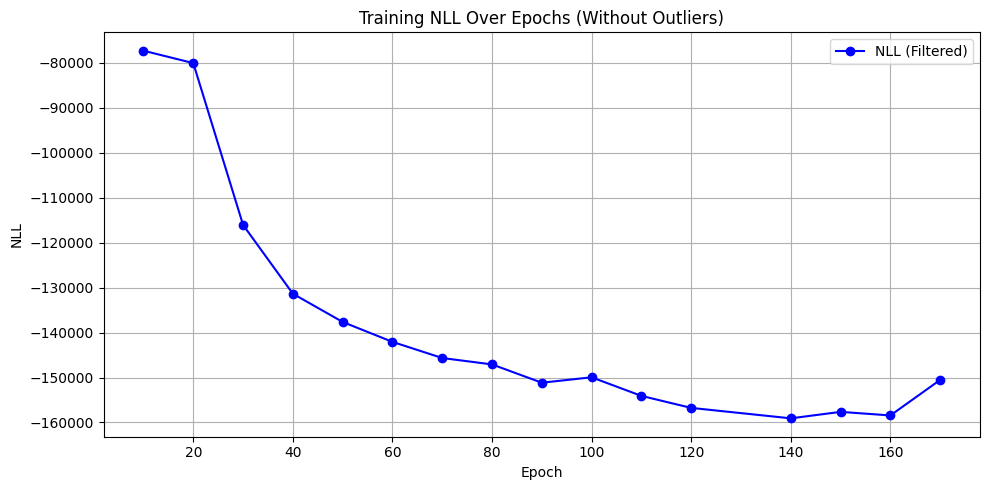

In [ ]:
import re
import matplotlib.pyplot as plt

# Path to your txt file
file_path = r'C:\Coding\mabe\MABe_2022_TVAE\checkpoints\test_mouse_jupyter_notebook\val_losses.txt'

# Lists to store epochs and NLL values
epochs = []
nll_values = []

# Read and parse the file
with open(file_path, 'r') as f:
    lines = f.readlines()

    for i in range(len(lines)):
        if "Validation losses @ epoch" in lines[i]:
            # Extract epoch number
            epoch_match = re.search(r'epoch (\d+)', lines[i])
            if epoch_match:
                epoch = int(epoch_match.group(1))
                nll_line = lines[i + 1]
                # Extract NLL value
                nll_match = re.search(r'NLL:\s*(-?\d+\.?\d*)', nll_line)
                if nll_match:
                    nll = float(nll_match.group(1))
                    epochs.append(epoch)
                    nll_values.append(nll)

import numpy as np

# Convert to NumPy array for easier manipulation
nll_array = np.array(nll_values)
epoch_array = np.array(epochs)

# Calculate IQR
q1 = np.percentile(nll_array, 25)
q3 = np.percentile(nll_array, 75)
iqr = q3 - q1

# Define bounds for non-outlier values
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filter out outliers
mask = (nll_array >= lower_bound) & (nll_array <= upper_bound)
filtered_epochs = epoch_array[mask]
filtered_nlls = nll_array[mask]

# Plotting filtered values
plt.figure(figsize=(10, 5))
plt.plot(filtered_epochs, filtered_nlls, marker='o', linestyle='-', color='blue', label='NLL (Filtered)')
plt.title('Training NLL Over Epochs (Without Outliers)')
plt.xlabel('Epoch')
plt.ylabel('NLL')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
dir_path = os.path.join(DATA_PATH, "train_annotation")

# Recursively find all .parquet files
ann_files = []
for root, _, files in os.walk(dir_path):
    for file in files:
        if file.endswith(".parquet"):
            ann_files.append(os.path.join(root, file))

# Read and concatenate all parquet files into one DataFrame
dfs = []
for f in ann_files:
    df = pd.read_parquet(f)
    fn = os.path.splitext(os.path.basename(f))[0]  # filename without extension
    df['video_file'] = fn
    dfs.append(df)

train_ann = pd.concat(dfs, ignore_index=True)

print(f"Number of files: {len(ann_files)}")
print(train_ann.head())
self_actions = train_ann.loc[train_ann['agent_id'] == train_ann['target_id'], 'action'].unique()

# print("Self actions:", ", ".join(self_actions))

# Pair actions: where agent_id != target_id, unique actions
pair_actions = train_ann.loc[train_ann['agent_id'] != train_ann['target_id'], 'action'].unique()

# print("\nPair actions:", ", ".join(pair_actions))
all_actions = np.unique(np.concatenate((self_actions, pair_actions)))
all_actions = list(all_actions)
all_actions.append("no_behavior")

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(np.array(all_actions).reshape(-1, 1))
print(len(all_actions))
del train_ann, ann_files

Number of files: 847
   agent_id  target_id action  start_frame  stop_frame  video_file
0         1          3  chase            2          54  1212811043
1         1          3  chase          128         234  1212811043
2         3          2  avoid          324         342  1212811043
3         3          1  avoid          324         342  1212811043
4         1          2  chase          942        1052  1212811043
38


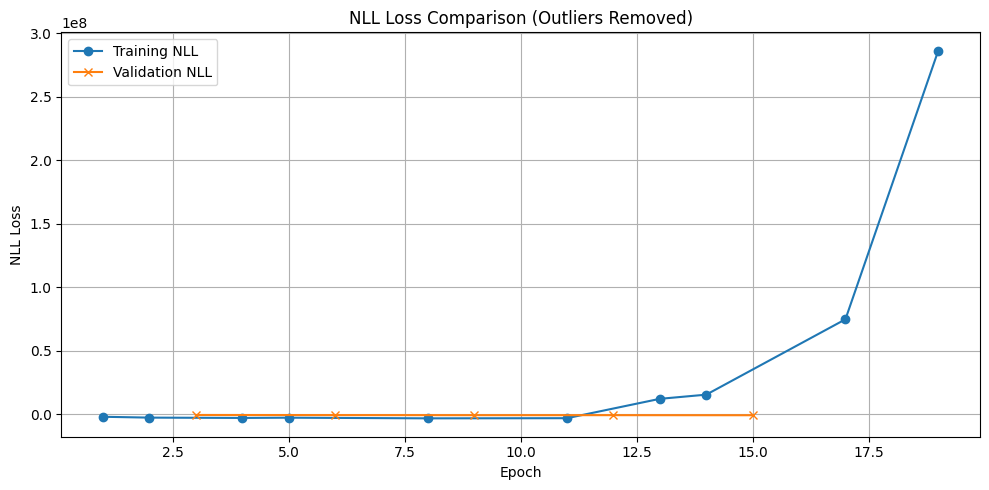

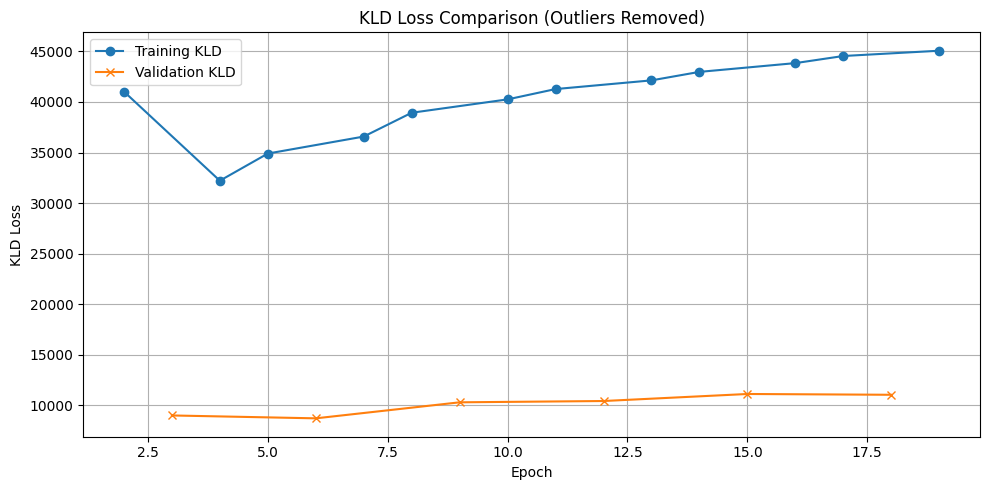

In [16]:
import matplotlib.pyplot as plt
import re
import numpy as np

def parse_loss_file(filepath, tag="Training"):
    with open(filepath, "r") as f:
        lines = f.readlines()

    epochs = []
    nlls = []
    klds = []

    epoch_pattern = re.compile(rf"-=-= {tag} losses @ epoch (\d+)")
    nll_pattern = re.compile(r"NLL:\s*(-?\d+\.?\d*)")
    kld_pattern = re.compile(r"KLD:\s*(\d+\.?\d*)")

    i = 0
    while i < len(lines):
        epoch_match = epoch_pattern.match(lines[i])
        if epoch_match:
            epoch = int(epoch_match.group(1))
            nll = float(nll_pattern.match(lines[i+1]).group(1))
            kld = float(kld_pattern.match(lines[i+2]).group(1))

            epochs.append(epoch)
            nlls.append(nll)
            klds.append(kld)

            i += 3
        else:
            i += 1

    return epochs, nlls, klds

def remove_outliers(epochs, values):
    """
    Removes outliers using the IQR method.
    Returns filtered epochs and values.
    """
    values_array = np.array(values)
    epochs_array = np.array(epochs)

    Q1 = np.percentile(values_array, 25)
    Q3 = np.percentile(values_array, 75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (values_array >= lower_bound) & (values_array <= upper_bound)

    return list(epochs_array[mask]), list(values_array[mask])

# Replace these with your actual file paths
training_file = r"C:\Coding\mabe\MABe_2022_TVAE\checkpoints\test_mouse_jupyter_notebook\train_losses.txt"
validation_file = r"C:\Coding\mabe\MABe_2022_TVAE\checkpoints\test_mouse_jupyter_notebook\val_losses.txt"

# Parse both files
train_epochs, train_nll, train_kld = parse_loss_file(training_file, "Training")
val_epochs, val_nll, val_kld = parse_loss_file(validation_file, "Validation")

# Remove outliers
train_epochs_nll, train_nll = remove_outliers(train_epochs, train_nll)
val_epochs_nll, val_nll = remove_outliers(val_epochs, val_nll)

train_epochs_kld, train_kld = remove_outliers(train_epochs, train_kld)
val_epochs_kld, val_kld = remove_outliers(val_epochs, val_kld)

# --- Plot NLL ---
plt.figure(figsize=(10, 5))
plt.plot(train_epochs_nll, train_nll, label="Training NLL", marker='o')
plt.plot(val_epochs_nll, val_nll, label="Validation NLL", marker='x')
plt.title("NLL Loss Comparison (Outliers Removed)")
plt.xlabel("Epoch")
plt.ylabel("NLL Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot KLD ---
plt.figure(figsize=(10, 5))
plt.plot(train_epochs_kld, train_kld, label="Training KLD", marker='o')
plt.plot(val_epochs_kld, val_kld, label="Validation KLD", marker='x')
plt.title("KLD Loss Comparison (Outliers Removed)")
plt.xlabel("Epoch")
plt.ylabel("KLD Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
remapping_dict = {
    "rear": "rear",
    "avoid": "avoid",
    "attack": "attack",
    "approach": "approach",
    "submit": "no_behavior",
    "chaseattack": "chase",
    "chase": "chase",
    "shepherd": "shepherd",
    "sniff": "sniff",
    "mount": "mount",
    "disengage": "disengage",
    "selfgroom": "selfgroom",
    "sniffgenital": "sniff",
    "sniffbody": "sniff",
    "sniffface": "sniff",
    "dominancemount": "mount",
    "attemptmount": "mount",
    "intromit": "no_behavior",
    "genitalgroom": "selfgroom",
    "reciprocalsniff": "sniff",
    "escape": "escape",
    "dominance": "dominance",
    "allogroom": "no_behavior",
    "ejaculate": "no_behavior",
    "defend": "defend",
    "dig": "dig",
    "rest": "rest",
    "climb": "climb",
    "run": "no_behavior",
    "dominancegroom": "no_behavior",
    "freeze": "no_behavior",
    "follow": "follow",
    "flinch": "no_behavior",
    "biteobject": "object",
    "exploreobject": "object",
    "tussle": "no_behavior",
    "huddle": "huddle"
}

In [16]:
dir_path = os.path.join(DATA_PATH, "train_annotation")

# Recursively find all .parquet files
ann_files = []
for root, _, files in os.walk(dir_path):
    for file in files:
        if file.endswith(".parquet"):
            ann_files.append(os.path.join(root, file))

# Read and concatenate all parquet files into one DataFrame
dfs = []
for f in ann_files:
    df = pd.read_parquet(f)
    fn = os.path.splitext(os.path.basename(f))[0]  # filename without extension
    df['video_file'] = fn
    dfs.append(df)

train_ann = pd.concat(dfs, ignore_index=True)

print(f"Number of files: {len(ann_files)}")
# print(train_ann.head(10))
self_actions = train_ann.loc[train_ann['agent_id'] == train_ann['target_id'], 'action'].map(remapping_dict).unique()

# print("Self actions:", ", ".join(self_actions))

# Pair actions: where agent_id != target_id, unique actions
pair_actions = train_ann.loc[train_ann['agent_id'] != train_ann['target_id'], 'action'].map(remapping_dict).unique()

# print("\nPair actions:", ", ".join(pair_actions))
all_actions = np.unique(np.concatenate((self_actions, pair_actions)))
all_actions = list(all_actions)
self_actions = list(self_actions)
pair_actions = list(pair_actions)
all_actions.append("no_behavior")
self_actions.insert(0, self_actions.pop(self_actions.index("no_behavior")))
pair_actions.insert(0, pair_actions.pop(pair_actions.index("no_behavior")))


solo_encoder = LabelEncoder()
solo_encoder.classes_ = np.array(self_actions)
dual_encoder = LabelEncoder()
dual_encoder.classes_ = np.array(pair_actions)
del train_ann, ann_files

agents = [1, 2, 3, 4]
agent_encoder = LabelEncoder()
agent_encoder.fit(np.array(agents).reshape(-1, 1))
print(len(self_actions), len(pair_actions))
print(pair_actions)

Number of files: 847
8 13
['no_behavior', 'chase', 'avoid', 'attack', 'approach', 'shepherd', 'sniff', 'mount', 'escape', 'disengage', 'dominance', 'defend', 'follow']


c:\Users\PC\.conda\envs\reg\lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [17]:
def split_files_into_train_test(path, train_df_path):
    all_files = []
    train_df = pd.read_csv(train_df_path)
    final_files = []

    # Gather all file paths
    for dirpath, _, filenames in os.walk(path):
        for filename in filenames:
            all_files.append(os.path.join(dirpath, filename))

    for _, row in train_df.iterrows():
        video_path = os.path.join(path, 'train_annotation', str(row['lab_id']), f"{row['video_id']}.parquet")
        if video_path not in all_files:
            continue
        else:
            final_files.append(video_path)


    train_files, test_files = train_test_split(final_files, test_size=0.1, random_state=42)

    return train_files, test_files

In [18]:
def build_chunks_test(path, train_df_path, all_files, chunk_size=CHUNK_SIZE, sub_seq_length=SUB_SEQ_LENGTH):
    chunks = []
    print(f"building test chunks with {len(all_files)} files")

    train_df = pd.read_csv(train_df_path)
    for _, row in train_df.iterrows():
        video_path = os.path.join(path, 'train_annotation', row['lab_id'], f"{row['video_id']}.parquet")
        if video_path not in all_files:
            continue

        df = pd.read_parquet(video_path)

        start_frame = df['start_frame'].iloc[0]
        stop_frame = df['stop_frame'].iloc[-1]

        for start_idx in range(start_frame, stop_frame + 1, chunk_size):
            start_frame2 = max(start_frame, start_idx - sub_seq_length // 2)
            chunk_end = min(start_idx + chunk_size + sub_seq_length // 2, stop_frame)
            chunks.append({
                'video_id': row['video_id'],
                'lab_id': str(row['lab_id']),
                'width': row['video_width_pix'],
                'height': row['video_height_pix'],
                'chunk_start': start_frame2,
                'chunk_end': chunk_end,
                'first_chunk': start_idx == start_frame,
                'last_chunk': chunk_end == stop_frame,
                'angle': 0
            })
    return chunks

def build_chunks(path, train_df_path, all_files, sub_seq_length=SUB_SEQ_LENGTH, min_chunk_len=22, max_chunk_len=2500):
    chunks = []
    print(f"Building chunks with {len(all_files)} files")

    train_df = pd.read_csv(train_df_path)

    for _, row in train_df.iterrows():
        video_path = os.path.join(path, 'train_annotation', str(row['lab_id']), f"{row['video_id']}.parquet")
        if video_path not in all_files:
            continue

        df = pd.read_parquet(video_path)
        df = df.sort_values('start_frame').reset_index(drop=True)

        final_frame = int(df['stop_frame'].iloc[-1])

        # --- 1️⃣ Behavior chunks ---
        for _, ann in df.iterrows():
            start_frame = int(ann['start_frame'])
            stop_frame = int(ann['stop_frame'])
            action = remapping_dict[ann['action']]
            length = stop_frame - start_frame + 1

            if length < min_chunk_len or length > max_chunk_len or action == "no_behavior":
                continue

            chunks.append({
                'video_id': row['video_id'],
                'lab_id': str(row['lab_id']),
                'width': row['video_width_pix'],
                'height': row['video_height_pix'],
                'chunk_start': start_frame,
                'chunk_end': stop_frame,
                'label': remapping_dict[ann['action']],
                'agent_id': ann['agent_id'],
                'target_id': ann['target_id'],
                'first_chunk': start_frame < 10,
                'last_chunk': stop_frame == final_frame,
                'angle': 0,
            })

        # --- 2️⃣ No-behavior chunks ---
        # prev_stop = 0
        # for _, ann in df.iterrows():
        #     start_frame = int(ann['start_frame'])
        #     if start_frame - prev_stop - 1 >= min_chunk_len:
        #         chunks.append({
        #             'video_id': row['video_id'],
        #             'lab_id': str(row['lab_id']),
        #             'width': row['video_width_pix'],
        #             'height': row['video_height_pix'],
        #             'chunk_start': prev_stop + 1,
        #             'chunk_end': start_frame - 1,
        #             'label': 'no_behavior',
        #             'agent_id': None,
        #             'target_id': None,
        #             'first_chunk': prev_stop < 10,
        #             'last_chunk': False,
        #             'angle': 0,
        #         })
        #     prev_stop = int(ann['stop_frame'])

        # # --- 3️⃣ Tail-end no-behavior chunk ---
        # if final_frame - prev_stop >= min_chunk_len:
        #     chunks.append({
        #         'video_id': row['video_id'],
        #         'lab_id': str(row['lab_id']),
        #         'width': row['video_width_pix'],
        #         'height': row['video_height_pix'],
        #         'chunk_start': prev_stop + 1,
        #         'chunk_end': final_frame,
        #         'label': 'no_behavior',
        #         'agent_id': None,
        #         'target_id': None,
        #         'first_chunk': False,
        #         'last_chunk': True,
        #         'angle': 0,
        #     })

    return chunks

In [19]:
from sklearn.utils import resample
from collections import defaultdict
import random
import copy

def stratified_resample(chunks, min_samples_per_class, max_samples_per_class):
    label_to_chunks = defaultdict(list)

    # Group chunks by label
    for chunk in chunks:
        label_to_chunks[chunk['label']].append(chunk)

    print("Original class distribution:")
    for label, samples in label_to_chunks.items():
        print(f"  Class '{label}': {len(samples)} chunks")

    resampled_chunks = []
    new_label_to_chunks = defaultdict(list)

    for label, samples in label_to_chunks.items():
        n_samples = len(samples)

        # Special handling for "no_behavior"
        # effective_max = 15000 if label == "no_behavior" else max_samples_per_class
        effective_max = max_samples_per_class

        # --- CASE 1: Underrepresented class ---
        if n_samples < min_samples_per_class:
            augmented = []

            # Step 1: Generate rotated variants for each chunk
            rotation_angles = [90, 180, 270]
            for chunk in samples:
                for angle in rotation_angles:
                    new_chunk = copy.deepcopy(chunk)
                    new_chunk["angle"] = angle
                    augmented.append(new_chunk)

            # Combine originals + augmented
            all_possible = samples + augmented

            # Step 2: If we have enough unique variants, pick min_samples_per_class
            if len(all_possible) >= min_samples_per_class:
                resampled = random.sample(all_possible, min_samples_per_class)
            else:
                # Step 3: If still short, oversample from this pool
                resampled = resample(all_possible,
                                     replace=True,
                                     n_samples=min_samples_per_class,
                                     random_state=42)

        # --- CASE 2: Overrepresented class ---
        elif n_samples > effective_max:
            resampled = random.sample(samples, effective_max)

        # --- CASE 3: Just right ---
        else:
            resampled = samples

        resampled_chunks.extend(resampled)
        new_label_to_chunks[label] = resampled

    print("\nPost-resampling class distribution:")
    for label, samples in new_label_to_chunks.items():
        print(f"  Class '{label}': {len(samples)} chunks")

    random.shuffle(resampled_chunks)
    return resampled_chunks


In [20]:
def reconstruct(states, actions, model, device):
    model = model.to(device)
    states = torch.from_numpy(states).to(device).float()
    actions = torch.from_numpy(actions).to(device).float()
    
    batch_log, reconstruction_set, embedding = model(
        states, 
        actions, 
        reconstruct = True,
        no_teacher_force = True
    )
    embedding = embedding.detach().requires_grad_(True)
    del states, actions
    torch.cuda.empty_cache()
    
    return embedding

In [21]:
# # Discarded Dataset Class

# class MABEModelDataset(Dataset):
#     def __init__(self, path, solo_encoder, dual_encoder, model, chunks):
#         self.agent_encoder = agent_encoder
#         self.path = path
#         self.solo_encoder = solo_encoder
#         self.dual_encoder = dual_encoder
#         self.chunk_size = CHUNK_SIZE
#         self.sub_seq_length = SUB_SEQ_LENGTH
#         self.sliding_window = SLIDING_WINDOW
#         self.model = model
#         self.all_files = []

#         self.chunks = chunks 
#         print(f"num chunks: {len(self.chunks)}")

#     def __len__(self):
#         return len(self.chunks)

#     def __getitem__(self, idx):
#         try:
#             info = self.chunks[idx]
#             video_id = info['video_id']
#             lab_id = info['lab_id']
#             width = info['width']
#             height = info['height']
#             chunk_start = info['chunk_start']
#             chunk_end = info['chunk_end']
#             is_start = info['first_chunk']
#             is_end = info['last_chunk']
#             # print(f"for video {video_id} {lab_id}")
        
#             half_window = self.sub_seq_length // 2  # 10 for length 21
        
#             # Load annotations once to know full video length
#             ann_df = pd.read_parquet(os.path.join(self.path, 'train_annotation', lab_id, f"{video_id}.parquet"))
#             total_video_length = ann_df['stop_frame'].max() + 1
        
#             # --- Adjust chunk boundaries for context frames ---
#             load_start = chunk_start
#             load_end = chunk_end
#             if not is_start:
#                 load_start = max(0, chunk_start - half_window)
#             if not is_end:
#                 load_end = min(total_video_length - 1, chunk_end + half_window)
        
#             # --- Load frames with context ---
#             df = load_and_process_video(video_id, lab_id, load_start, load_end)
#             vec_seq = df.to_numpy()
#             vec_seq = np.where(np.isnan(vec_seq), -1, vec_seq)
#             vec_seq = normalize(vec_seq, width, height)
        
#             # --- Pad edges only if we’re at start or end ---
#             if is_start:
#                 left_pad = np.repeat(vec_seq[0:1], half_window, axis=0)
#                 vec_seq = np.concatenate([left_pad, vec_seq], axis=0)
        
#             if is_end:
#                 right_pad = np.repeat(vec_seq[-1:], half_window, axis=0)
#                 vec_seq = np.concatenate([vec_seq, right_pad], axis=0)
        
#             # --- Recompute true valid range within vec_seq ---
#             start_offset = 0 if is_start else half_window
#             end_offset = vec_seq.shape[0] - half_window if is_end else vec_seq.shape[0] - half_window
        
#             # --- Build centered subsequences (length = 21) ---
#             sub_seqs = np.stack([
#                 vec_seq[i - half_window:i + half_window + 1]
#                 for i in range(half_window, vec_seq.shape[0] - half_window)
#             ])  # shape: [num_frames_in_chunk, 21, state_dim]
        
#             original_len = sub_seqs.shape[0]
        
#             # --- Build frame-level labels for the original (unpadded) chunk ---
#             frame_labels = {i: np.full(original_len, 'no_behavior', dtype=object) for i in range(1, 5)}
#             frame_targets = {i: np.full(original_len, 0, dtype=int) for i in range(1, 5)}
        
#             # Filter annotations that overlap with current chunk
#             for _, row in ann_df.iterrows():
#                 start, stop, action, agent, target = row['start_frame'], row['stop_frame'], row['action'], row['agent_id'], row['target_id']
        
#                 # Skip if outside current chunk boundaries
#                 if stop < chunk_start or start > chunk_end:
#                     continue
        
#                 # Convert to local frame indices within current chunk
#                 local_start = max(0, start - chunk_start)
#                 local_stop = min(original_len - 1, stop - chunk_start)
        
#                 frame_labels[agent][local_start:local_stop + 1] = action
#                 frame_targets[agent][local_start:local_stop + 1] = target
        
#             # --- Extract labels for the center frame (index 10) of each subsequence ---
#             mouse_labels = {i: [] for i in range(1, 5)}
#             mouse_targets = {i: [] for i in range(1, 5)}
        
#             for i in range(original_len):
#                 center_frame = i + chunk_start  # actual frame index in video
#                 for mouse_id in range(1, 5):
#                     label = frame_labels[mouse_id][i]
#                     target = frame_targets[mouse_id][i]
#                     mouse_labels[mouse_id].append(label)
#                     mouse_targets[mouse_id].append(target)
        
#             num_agents = 4
#             num_solo_classes = len(self.solo_encoder.classes_)
#             num_dual_classes = len(self.dual_encoder.classes_)

#             # Shapes:
#             # solo_labels: [T, 4]  (long ints: class indices for solo encoder)
#             # dual_labels: [T, 4, 4] (long ints: class indices for dual encoder; diagonal stays 0)
#             solo_labels = torch.zeros((original_len, num_agents), dtype=torch.long)
#             dual_labels = torch.zeros((original_len, num_agents, num_agents), dtype=torch.long)

#             for f in range(original_len):
#                 for agent in range(1, num_agents + 1):
#                     action_str = frame_labels[agent][f]  # e.g. 'attack' or 'no_behavior'

#                     # --- SOLO: encode in separate solo_labels matrix ---
#                     if action_str in self_actions:
#                         solo_idx = self.solo_encoder.transform([action_str])[0]
#                         solo_labels[f, agent - 1] = solo_idx

#                     # --- DUAL: encode only non-self, non-zero targets ---
#                     target = frame_targets[agent][f]  # 0 means no target
#                     if target != 0 and target != agent:
#                         target_idx = self.agent_encoder.transform([target])[0]  # e.g. 0..3
#                         dual_idx = self.dual_encoder.transform([action_str])[0]
#                         dual_labels[f, agent - 1, target_idx] = dual_idx
#             states = sub_seqs
#             actions = states[:, 1:] - states[:, :-1]

#             has_action = torch.zeros((original_len, 1), dtype=torch.long)

#             for f in range(original_len):
#                 solo_nonzero = (solo_labels[f] != 0).any()  # if any agent has a solo action
#                 dual_nonzero = (dual_labels[f] != 0).any()  # if any agent-target pair has a dual action
#                 if solo_nonzero or dual_nonzero:
#                     has_action[f, 0] = 1
        
#             # --- Sanity check ---
#             # print(f"Chunk [{chunk_start}, {chunk_end}] | vec_seq: {vec_seq.shape} | subseqs: {sub_seqs.shape}")
#             # print(f"mouse 1 labels shape: {mouse_label_tensors[1].shape}")
#             # print(f"mouse 2 labels shape: {mouse_label_tensors[2].shape}")
#             # print(f"mouse 3 labels shape: {mouse_label_tensors[3].shape}")
#             # print(f"mouse 4 labels shape: {mouse_label_tensors[4].shape}")
        
#             # for i in range(min(10, mouse_label_tensors[1].shape[0])):  # print first few
#             #     # for j in range(1, 5):
#             #     j = 2
#             #     print(f"Frame {i + chunk_start} | M{j} action: {self.encoder.inverse_transform(mouse_label_tensors[j][i].reshape(1, -1))}")
        
#             return reconstruct(states, actions, self.model, "cuda"), solo_labels, dual_labels, has_action
#         except:
#             return None
        
# class MABEModelDatasetEval(Dataset):
#     def __init__(self, path, solo_encoder, dual_encoder, model, chunks):
#         self.agent_encoder = agent_encoder
#         self.model = model
#         self.path = path
#         self.solo_encoder = solo_encoder
#         self.dual_encoder = dual_encoder
#         self.chunk_size = CHUNK_SIZE
#         self.sub_seq_length = SUB_SEQ_LENGTH
#         self.sliding_window = SLIDING_WINDOW
#         self.all_files = []

#         self.chunks = chunks 
#         print(f"num chunks: {len(self.chunks)}")

#     def __len__(self):
#         return len(self.chunks)

#     def __getitem__(self, idx):
#         try:
#             info = self.chunks[idx]
#             video_id = info['video_id']
#             lab_id = info['lab_id']
#             width = info['width']
#             height = info['height']
#             chunk_start = info['chunk_start']
#             chunk_end = info['chunk_end']
#             is_start = info['first_chunk']
#             is_end = info['last_chunk']
#             # print(f"for video {video_id} {lab_id}")
        
#             half_window = self.sub_seq_length // 2  # 10 for length 21
        
#             # Load annotations once to know full video length
#             ann_df = pd.read_parquet(os.path.join(self.path, 'train_annotation', lab_id, f"{video_id}.parquet"))
#             total_video_length = ann_df['stop_frame'].max() + 1
        
#             # --- Adjust chunk boundaries for context frames ---
#             load_start = chunk_start
#             load_end = chunk_end
#             if not is_start:
#                 load_start = max(0, chunk_start - half_window)
#             if not is_end:
#                 load_end = min(total_video_length - 1, chunk_end + half_window)
        
#             # --- Load frames with context ---
#             df = load_and_process_video(video_id, lab_id, load_start, load_end)
#             vec_seq = df.to_numpy()
#             vec_seq = np.where(np.isnan(vec_seq), -1, vec_seq)
#             vec_seq = normalize(vec_seq, width, height)
        
#             # --- Pad edges only if we’re at start or end ---
#             if is_start:
#                 left_pad = np.repeat(vec_seq[0:1], half_window, axis=0)
#                 vec_seq = np.concatenate([left_pad, vec_seq], axis=0)
        
#             if is_end:
#                 right_pad = np.repeat(vec_seq[-1:], half_window, axis=0)
#                 vec_seq = np.concatenate([vec_seq, right_pad], axis=0)
        
#             # --- Recompute true valid range within vec_seq ---
#             start_offset = 0 if is_start else half_window
#             end_offset = vec_seq.shape[0] - half_window if is_end else vec_seq.shape[0] - half_window
        
#             # --- Build centered subsequences (length = 21) ---
#             sub_seqs = np.stack([
#                 vec_seq[i - half_window:i + half_window + 1]
#                 for i in range(half_window, vec_seq.shape[0] - half_window)
#             ])  # shape: [num_frames_in_chunk, 21, state_dim]
        
#             original_len = sub_seqs.shape[0]
        
#             # --- Build frame-level labels for the original (unpadded) chunk ---
#             frame_labels = {i: np.full(original_len, 'no_behavior', dtype=object) for i in range(1, 5)}
#             frame_targets = {i: np.full(original_len, 0, dtype=int) for i in range(1, 5)}
        
#             # Filter annotations that overlap with current chunk
#             for _, row in ann_df.iterrows():
#                 start, stop, action, agent, target = row['start_frame'], row['stop_frame'], row['action'], row['agent_id'], row['target_id']
        
#                 # Skip if outside current chunk boundaries
#                 if stop < chunk_start or start > chunk_end:
#                     continue
        
#                 # Convert to local frame indices within current chunk
#                 local_start = max(0, start - chunk_start)
#                 local_stop = min(original_len - 1, stop - chunk_start)
        
#                 frame_labels[agent][local_start:local_stop + 1] = action
#                 frame_targets[agent][local_start:local_stop + 1] = target
        
#             # --- Extract labels for the center frame (index 10) of each subsequence ---
#             mouse_labels = {i: [] for i in range(1, 5)}
#             mouse_targets = {i: [] for i in range(1, 5)}
        
#             for i in range(original_len):
#                 center_frame = i + chunk_start  # actual frame index in video
#                 for mouse_id in range(1, 5):
#                     label = frame_labels[mouse_id][i]
#                     target = frame_targets[mouse_id][i]
#                     mouse_labels[mouse_id].append(label)
#                     mouse_targets[mouse_id].append(target)
        
#             num_agents = 4
#             num_solo_classes = len(self.solo_encoder.classes_)
#             num_dual_classes = len(self.dual_encoder.classes_)

#             # Shapes:
#             # solo_labels: [T, 4]  (long ints: class indices for solo encoder)
#             # dual_labels: [T, 4, 4] (long ints: class indices for dual encoder; diagonal stays 0)
#             solo_labels = torch.zeros((original_len, num_agents), dtype=torch.long)
#             dual_labels = torch.zeros((original_len, num_agents, num_agents), dtype=torch.long)

#             for f in range(original_len):
#                 for agent in range(1, num_agents + 1):
#                     action_str = frame_labels[agent][f]  # e.g. 'attack' or 'no_behavior'

#                     # --- SOLO: encode in separate solo_labels matrix ---
#                     if action_str in self_actions:
#                         solo_idx = self.solo_encoder.transform([action_str])[0]
#                         solo_labels[f, agent - 1] = solo_idx

#                     # --- DUAL: encode only non-self, non-zero targets ---
#                     target = frame_targets[agent][f]  # 0 means no target
#                     if target != 0 and target != agent:
#                         target_idx = self.agent_encoder.transform([target])[0]  # e.g. 0..3
#                         dual_idx = self.dual_encoder.transform([action_str])[0]
#                         dual_labels[f, agent - 1, target_idx] = dual_idx
#             states = sub_seqs
#             actions = states[:, 1:] - states[:, :-1]

#             has_action = torch.zeros((original_len, 1), dtype=torch.long)

#             for f in range(original_len):
#                 solo_nonzero = (solo_labels[f] != 0).any()  # if any agent has a solo action
#                 dual_nonzero = (dual_labels[f] != 0).any()  # if any agent-target pair has a dual action
#                 if solo_nonzero or dual_nonzero:
#                     has_action[f, 0] = 1
        
#             # --- Sanity check ---
#             # print(f"Chunk [{chunk_start}, {chunk_end}] | vec_seq: {vec_seq.shape} | subseqs: {sub_seqs.shape}")
#             # print(f"mouse 1 labels shape: {mouse_label_tensors[1].shape}")
#             # print(f"mouse 2 labels shape: {mouse_label_tensors[2].shape}")
#             # print(f"mouse 3 labels shape: {mouse_label_tensors[3].shape}")
#             # print(f"mouse 4 labels shape: {mouse_label_tensors[4].shape}")
        
#             # for i in range(min(10, mouse_label_tensors[1].shape[0])):  # print first few
#             #     # for j in range(1, 5):
#             #     j = 2
#             #     print(f"Frame {i + chunk_start} | M{j} action: {self.encoder.inverse_transform(mouse_label_tensors[j][i].reshape(1, -1))}")
        
#             return reconstruct(states, actions, self.model, "cuda"), solo_labels, dual_labels, has_action, video_id, chunk_start
#         except:
#             return None
        




In [22]:
class MABEModelDataset(Dataset):
    def __init__(self, path, solo_encoder, dual_encoder, model, chunks):
        self.agent_encoder = agent_encoder
        self.path = path
        self.solo_encoder = solo_encoder
        self.dual_encoder = dual_encoder
        self.chunk_size = CHUNK_SIZE
        self.sub_seq_length = SUB_SEQ_LENGTH
        self.sliding_window = SLIDING_WINDOW
        self.all_files = []
        self.model = model

        self.chunks = chunks 
        print(f"num chunks: {len(self.chunks)}")

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        try:
            info = self.chunks[idx]
            video_id = info['video_id']
            lab_id = info['lab_id']
            width = info['width']
            height = info['height']
            chunk_start = info['chunk_start']
            chunk_end = info['chunk_end']
            is_start = info['first_chunk']
            is_end = info['last_chunk']
            angle = info['angle']
            # print(f"for video {video_id} {lab_id} {chunk_start} {chunk_end}")
        
            half_window = self.sub_seq_length // 2  # 10 for length 21
        
            # Load annotations once to know full video length
            ann_df = pd.read_parquet(os.path.join(self.path, 'train_annotation', lab_id, f"{video_id}.parquet"))
            total_video_length = ann_df['stop_frame'].max() + 1
        
            # --- Adjust chunk boundaries for context frames ---
            load_start = chunk_start
            load_end = chunk_end
            if not is_start:
                load_start = max(0, chunk_start - half_window)
            if not is_end:
                load_end = min(total_video_length - 1, chunk_end + half_window)
        
            # --- Load frames with context ---
            df = load_and_process_video(video_id, lab_id, load_start, load_end, width, height, angle=angle)
            vec_seq = df.to_numpy()
            vec_seq = np.where(np.isnan(vec_seq), -1, vec_seq)
            if angle in [90, 270]:
                vec_seq = normalize(vec_seq, height, width)
            else:
                vec_seq = normalize(vec_seq, width, height)
        
            # --- Pad edges only if we’re at start or end ---
            if is_start:
                left_pad = np.repeat(vec_seq[0:1], half_window, axis=0)
                vec_seq = np.concatenate([left_pad, vec_seq], axis=0)
        
            if is_end:
                right_pad = np.repeat(vec_seq[-1:], half_window, axis=0)
                vec_seq = np.concatenate([vec_seq, right_pad], axis=0)
        
            # --- Recompute true valid range within vec_seq ---
            start_offset = 0 if is_start else half_window
            end_offset = vec_seq.shape[0] - half_window if is_end else vec_seq.shape[0] - half_window
        
            # --- Build centered subsequences (length = 21) ---
            sub_seqs = np.stack([
                vec_seq[i - half_window:i + half_window + 1]
                for i in range(half_window, vec_seq.shape[0] - half_window)
            ])  # shape: [num_frames_in_chunk, 21, state_dim]
        
            original_len = sub_seqs.shape[0]
        
            # --- Build frame-level labels for the original (unpadded) chunk ---
            frame_labels = {i: np.full(original_len, 'no_behavior', dtype=object) for i in range(1, 5)}
            frame_targets = {i: np.full(original_len, 0, dtype=int) for i in range(1, 5)}
        
            # Filter annotations that overlap with current chunk
            for _, row in ann_df.iterrows():
                start, stop, action, agent, target = row['start_frame'], row['stop_frame'], remapping_dict[row['action']], row['agent_id'], row['target_id']
        
                # Skip if outside current chunk boundaries
                if stop < chunk_start or start > chunk_end or action == "no_behavior":
                    continue
        
                # Convert to local frame indices within current chunk
                local_start = max(0, start - chunk_start)
                local_stop = min(original_len - 1, stop - chunk_start)
        
                frame_labels[agent][local_start:local_stop + 1] = action
                frame_targets[agent][local_start:local_stop + 1] = target
        
            # --- Extract labels for the center frame (index 10) of each subsequence ---
            mouse_labels = {i: [] for i in range(1, 5)}
            mouse_targets = {i: [] for i in range(1, 5)}
        
            for i in range(original_len):
                center_frame = i + chunk_start  # actual frame index in video
                for mouse_id in range(1, 5):
                    label = frame_labels[mouse_id][i]
                    target = frame_targets[mouse_id][i]
                    mouse_labels[mouse_id].append(label)
                    mouse_targets[mouse_id].append(target)
        
            num_agents = 4
            num_solo_classes = len(self.solo_encoder.classes_)
            num_dual_classes = len(self.dual_encoder.classes_)

            # Shapes:
            # solo_labels: [T, 4]  (long ints: class indices for solo encoder)
            # dual_labels: [T, 4, 4] (long ints: class indices for dual encoder; diagonal stays 0)
            solo_labels = torch.zeros((original_len, num_agents), dtype=torch.long)
            dual_labels = torch.zeros((original_len, num_agents, num_agents), dtype=torch.long)

            for f in range(original_len):
                for agent in range(1, num_agents + 1):
                    action_str = frame_labels[agent][f]  # e.g. 'attack' or 'no_behavior'

                    # --- SOLO: encode in separate solo_labels matrix ---
                    if action_str in self_actions:
                        solo_idx = self.solo_encoder.transform([action_str])[0]
                        solo_labels[f, agent - 1] = solo_idx

                    # --- DUAL: encode only non-self, non-zero targets ---
                    target = frame_targets[agent][f]  # 0 means no target
                    if target != 0 and target != agent:
                        target_idx = self.agent_encoder.transform([target])[0]  # e.g. 0..3
                        dual_idx = self.dual_encoder.transform([action_str])[0]
                        dual_labels[f, agent - 1, target_idx] = dual_idx
            states = sub_seqs
            actions = states[:, 1:] - states[:, :-1]

            has_action = torch.zeros((original_len, 1), dtype=torch.long)

            for f in range(original_len):
                solo_nonzero = (solo_labels[f] != 0).any()  # if any agent has a solo action
                dual_nonzero = (dual_labels[f] != 0).any()  # if any agent-target pair has a dual action
                if solo_nonzero or dual_nonzero:
                    has_action[f, 0] = 1
        
            return (
                reconstruct(states, actions, self.model, "cuda"),
                solo_labels,
                dual_labels,
                has_action,
                # video_id,
                # chunk_start
            )
        except:
            print("returning None")
            return None
    
class MABEModelDatasetEval(Dataset):
    def __init__(self, path, solo_encoder, dual_encoder, model, chunks):
        self.agent_encoder = agent_encoder
        self.path = path
        self.solo_encoder = solo_encoder
        self.dual_encoder = dual_encoder
        self.chunk_size = CHUNK_SIZE
        self.sub_seq_length = SUB_SEQ_LENGTH
        self.sliding_window = SLIDING_WINDOW
        self.all_files = []
        self.model = model

        self.chunks = chunks 
        print(f"num chunks: {len(self.chunks)}")

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        # try:
        info = self.chunks[idx]
        video_id = info['video_id']
        lab_id = info['lab_id']
        width = info['width']
        height = info['height']
        chunk_start = info['chunk_start']
        chunk_end = info['chunk_end']
        is_start = info['first_chunk']
        is_end = info['last_chunk']
        angle = info['angle']
        # print(f"for video {video_id} {lab_id} {chunk_start} {chunk_end}")
    
        half_window = self.sub_seq_length // 2  # 10 for length 21
    
        # Load annotations once to know full video length
        ann_df = pd.read_parquet(os.path.join(self.path, 'train_annotation', lab_id, f"{video_id}.parquet"))
        total_video_length = ann_df['stop_frame'].max() + 1
    
        # --- Adjust chunk boundaries for context frames ---
        load_start = chunk_start
        load_end = chunk_end
        if not is_start:
            load_start = max(0, chunk_start - half_window)
        if not is_end:
            load_end = min(total_video_length - 1, chunk_end + half_window)
    
        # --- Load frames with context ---
        df = load_and_process_video(video_id, lab_id, load_start, load_end, width, height, angle=angle)
        vec_seq = df.to_numpy()
        vec_seq = np.where(np.isnan(vec_seq), -1, vec_seq)
        if angle in [90, 270]:
            vec_seq = normalize(vec_seq, height, width)
        else:
            vec_seq = normalize(vec_seq, width, height)
        vec_seq = normalize(vec_seq, width, height)
    
        # --- Pad edges only if we’re at start or end ---
        if is_start:
            left_pad = np.repeat(vec_seq[0:1], half_window, axis=0)
            vec_seq = np.concatenate([left_pad, vec_seq], axis=0)
    
        if is_end:
            right_pad = np.repeat(vec_seq[-1:], half_window, axis=0)
            vec_seq = np.concatenate([vec_seq, right_pad], axis=0)
    
        # --- Recompute true valid range within vec_seq ---
        start_offset = 0 if is_start else half_window
        end_offset = vec_seq.shape[0] - half_window if is_end else vec_seq.shape[0] - half_window
    
        # --- Build centered subsequences (length = 21) ---
        sub_seqs = np.stack([
            vec_seq[i - half_window:i + half_window + 1]
            for i in range(half_window, vec_seq.shape[0] - half_window)
        ])  # shape: [num_frames_in_chunk, 21, state_dim]
    
        original_len = sub_seqs.shape[0]
    
        # --- Build frame-level labels for the original (unpadded) chunk ---
        frame_labels = {i: np.full(original_len, 'no_behavior', dtype=object) for i in range(1, 5)}
        frame_targets = {i: np.full(original_len, 0, dtype=int) for i in range(1, 5)}
    
        # Filter annotations that overlap with current chunk
        for _, row in ann_df.iterrows():
            start, stop, action, agent, target = row['start_frame'], row['stop_frame'], remapping_dict[row['action']], row['agent_id'], row['target_id']
    
            # Skip if outside current chunk boundaries
            if stop < chunk_start or start > chunk_end or action == "no_behavior":
                continue
    
            # Convert to local frame indices within current chunk
            local_start = max(0, start - chunk_start)
            local_stop = min(original_len - 1, stop - chunk_start)
    
            frame_labels[agent][local_start:local_stop + 1] = action
            frame_targets[agent][local_start:local_stop + 1] = target
    
        # --- Extract labels for the center frame (index 10) of each subsequence ---
        mouse_labels = {i: [] for i in range(1, 5)}
        mouse_targets = {i: [] for i in range(1, 5)}
    
        for i in range(original_len):
            center_frame = i + chunk_start  # actual frame index in video
            for mouse_id in range(1, 5):
                label = frame_labels[mouse_id][i]
                target = frame_targets[mouse_id][i]
                mouse_labels[mouse_id].append(label)
                mouse_targets[mouse_id].append(target)
    
        num_agents = 4
        num_solo_classes = len(self.solo_encoder.classes_)
        num_dual_classes = len(self.dual_encoder.classes_)

        # Shapes:
        # solo_labels: [T, 4]  (long ints: class indices for solo encoder)
        # dual_labels: [T, 4, 4] (long ints: class indices for dual encoder; diagonal stays 0)
        solo_labels = torch.zeros((original_len, num_agents), dtype=torch.long)
        dual_labels = torch.zeros((original_len, num_agents, num_agents), dtype=torch.long)

        for f in range(original_len):
            for agent in range(1, num_agents + 1):
                action_str = frame_labels[agent][f]  # e.g. 'attack' or 'no_behavior'

                # --- SOLO: encode in separate solo_labels matrix ---
                if action_str in self_actions:
                    solo_idx = self.solo_encoder.transform([action_str])[0]
                    solo_labels[f, agent - 1] = solo_idx

                # --- DUAL: encode only non-self, non-zero targets ---
                target = frame_targets[agent][f]  # 0 means no target
                if target != 0 and target != agent:
                    target_idx = self.agent_encoder.transform([target])[0]  # e.g. 0..3
                    dual_idx = self.dual_encoder.transform([action_str])[0]
                    dual_labels[f, agent - 1, target_idx] = dual_idx
        states = sub_seqs
        actions = states[:, 1:] - states[:, :-1]

        has_action = torch.zeros((original_len, 1), dtype=torch.long)

        for f in range(original_len):
            solo_nonzero = (solo_labels[f] != 0).any()  # if any agent has a solo action
            dual_nonzero = (dual_labels[f] != 0).any()  # if any agent-target pair has a dual action
            if solo_nonzero or dual_nonzero:
                has_action[f, 0] = 1
    
        return (
            reconstruct(states, actions, self.model, "cuda"),
            solo_labels,
            dual_labels,
            has_action,
            video_id,
            chunk_start
        )
        # except:
        #     print("returning None")
        #     return None

In [23]:
# # Testing the dataset
# model = TVAE(model_config)
# model.eval()  # Set to evaluation mode (disables dropout, batchnorm behavior)
# for param in model.parameters():
#     param.requires_grad = False
# state_dict = torch.load(r'C:\Coding\mabe\checkpoints\test_mouse_jupyter_notebook\60.pt')  # or 'cuda' if you're using GPU
# model.load_state_dict(state_dict)
# dset = MABEModelDataset(DATA_PATH, CACHE_PATH, encoder, agent_encoder, model)
# i = 0
# for batch in dset:
#     a, b, c = batch
#     break
# print(f"embedding shape: {a.shape}")

In [24]:
class MultiHeadActionModel(nn.Module):
    def __init__(self, embed_dim=32, hidden_dim=64, num_solo_classes=8, num_dual_classes=13):
        super().__init__()
        
        # --- SOLO Action Head ---
        self.solo_mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 4 * num_solo_classes)
        )

        # --- DUAL Action Head ---
        self.dual_mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 16 * num_dual_classes)
        )

        # --- HAS-ACTION (binary) Head ---
        # self.action_conf_head = nn.Sequential(
        #     nn.Linear(embed_dim, 32),
        #     nn.ReLU(),
        #     nn.Dropout(0.2),
        #     nn.Linear(32, 16),
        #     nn.ReLU(),
        #     nn.Dropout(0.2),
        #     nn.Linear(16, 1),
        #     # nn.Sigmoid(),
        # )

        self.num_solo_classes = num_solo_classes
        self.num_dual_classes = num_dual_classes

    def forward(self, embed, return_sigmoid=False):
        """
        Args:
            solo_embed: Tensor of shape [B, embed_dim] for solo actions
            dual_embed_pair: Tensor of shape [B, 2 * embed_dim] for dual actions
            return_sigmoid: if True, applies sigmoid on the has-action output
        Returns:
            dict with keys: 'solo_logits', 'dual_logits', 'has_action'
        """
        B = embed.shape[0]

        solo_logits = self.solo_mlp(embed)
        dual_logits = self.dual_mlp(embed)
        # has_action = self.action_conf_head(embed)

        solo_logits = solo_logits.view(B, 4, self.num_solo_classes)
        dual_logits = dual_logits.view(B, 4, 4, self.num_dual_classes)
        # if return_sigmoid:
        #     has_action = torch.sigmoid(has_action)

        return solo_logits, dual_logits#, has_action


# class MABEModel(nn.Module):
#     def __init__(self, input_dim):
#         super(MABEModel, self).__init__()

#         # Define shared architecture for actions and targets
#         def make_head(output_dim):
#             return nn.Sequential(
#                 nn.Linear(in_features=input_dim, out_features=36),
#                 nn.ReLU(),
#                 nn.Linear(in_features=36, out_features=output_dim)
#             )

#         # Action heads (4 mice)
#         self.action_mouse1 = make_head(38)
#         self.action_mouse2 = make_head(38)
#         self.action_mouse3 = make_head(38)
#         self.action_mouse4 = make_head(38)

#         # Target heads (4 mice)
#         self.target_mouse1 = make_head(5)
#         self.target_mouse2 = make_head(5)
#         self.target_mouse3 = make_head(5)
#         self.target_mouse4 = make_head(5)

#     def forward(self, x):
#         # Predict actions for 4 mice
#         pred_action_mouse1 = self.action_mouse1(x)
#         pred_action_mouse2 = self.action_mouse2(x)
#         pred_action_mouse3 = self.action_mouse3(x)
#         pred_action_mouse4 = self.action_mouse4(x)

#         # Predict targets for 4 mice
#         pred_target_mouse1 = self.target_mouse1(x)
#         pred_target_mouse2 = self.target_mouse2(x)
#         pred_target_mouse3 = self.target_mouse3(x)
#         pred_target_mouse4 = self.target_mouse4(x)

#         return (
#             pred_action_mouse1,
#             pred_action_mouse2,
#             pred_action_mouse3,
#             pred_action_mouse4,
#             pred_target_mouse1,
#             pred_target_mouse2,
#             pred_target_mouse3,
#             pred_target_mouse4
#         )

In [25]:
def collate_fn(batch):
    # filter out Nones
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    return torch.utils.data.default_collate(batch)

In [26]:
model = TVAE(model_config)
model.eval()  # Set to evaluation mode (disables dropout, batchnorm behavior)
for param in model.parameters():
    param.requires_grad = False
state_dict = torch.load(r'C:\Coding\mabe\checkpoints\test_mouse_jupyter_notebook\60.pt')  # or 'cuda' if you're using GPU
model.load_state_dict(state_dict)


train_files, test_files = split_files_into_train_test(DATA_PATH, os.path.join(DATA_PATH, 'train.csv'))
train_chunks = build_chunks(DATA_PATH, os.path.join(DATA_PATH, "train.csv"), train_files)
# train_chunks = filter_chunks_by_inactive_frames(train_chunks, 100)

train_chunks = stratified_resample(train_chunks, min_samples_per_class=1250, max_samples_per_class=2500)
test_chunks = build_chunks(DATA_PATH, os.path.join(DATA_PATH, "train.csv"), test_files)
# train_chunks, test_chunks = train_chunks[:50], test_chunks[:50]
train_dataset = MABEModelDataset(DATA_PATH, solo_encoder, dual_encoder, model, train_chunks)
test_dataset = MABEModelDatasetEval(DATA_PATH, solo_encoder, dual_encoder, model, test_chunks)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

N = 4  # number of agents

mabemodel = MultiHeadActionModel()
state_dict = torch.load(r'C:\Coding\mabe\MABe_2022_TVAE\vae_model_epoch3.pt')  
mabemodel.load_state_dict(state_dict)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mabemodel.to(device)

optimizer = torch.optim.Adam(mabemodel.parameters(), lr=1e-3)

weights = torch.ones(len(solo_encoder.classes_))
weights = weights.to("cuda")
weights[0] = 0.01
weights2 = torch.ones(len(dual_encoder.classes_))
weights2 = weights2.to("cuda")
weights2[0] = 0.01
pos_weight = torch.tensor([0.1]).to("cuda")

solo_loss_fn = nn.CrossEntropyLoss(weight=weights)
dual_loss_fn = nn.CrossEntropyLoss(weight=weights2)
has_action_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
epochs = 100

C:\Users\PC\AppData\Local\Temp\ipykernel_5624\175706157.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(r'C:\Coding\mabe\checkpoints\test_mouse_j

Building chunks with 762 files
Original class distribution:
  Class 'rear': 3410 chunks
  Class 'avoid': 500 chunks
  Class 'attack': 4628 chunks
  Class 'approach': 1588 chunks
  Class 'chase': 514 chunks
  Class 'shepherd': 153 chunks
  Class 'sniff': 27086 chunks
  Class 'mount': 2569 chunks
  Class 'disengage': 214 chunks
  Class 'selfgroom': 875 chunks
  Class 'escape': 1061 chunks
  Class 'dominance': 294 chunks
  Class 'defend': 779 chunks
  Class 'dig': 929 chunks
  Class 'rest': 232 chunks
  Class 'climb': 868 chunks
  Class 'follow': 153 chunks
  Class 'object': 89 chunks
  Class 'huddle': 183 chunks

Post-resampling class distribution:
  Class 'rear': 2500 chunks
  Class 'avoid': 1250 chunks
  Class 'attack': 2500 chunks
  Class 'approach': 1588 chunks
  Class 'chase': 1250 chunks
  Class 'shepherd': 1250 chunks
  Class 'sniff': 2500 chunks
  Class 'mount': 2500 chunks
  Class 'disengage': 1250 chunks
  Class 'selfgroom': 1250 chunks
  Class 'escape': 1250 chunks
  Class 'do

C:\Users\PC\AppData\Local\Temp\ipykernel_5624\175706157.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(r'C:\Coding\mabe\MABe_2022_TVAE\vae_mode

In [31]:
"""F Beta customized for the data format of the MABe challenge — now extended to show precision, recall, accuracy, etc."""

import json
from collections import defaultdict
import pandas as pd
import polars as pl


class HostVisibleError(Exception):
    pass


def compute_metrics(tps, fps, fns, beta):
    """Return precision, recall, fbeta, accuracy."""
    tp = tps
    fp = fps
    fn = fns

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    if precision == 0 and recall == 0:
        fbeta = 0.0
    else:
        fbeta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall)

    # For these tasks: accuracy = tp / (tp + fp + fn)
    denom = tp + fp + fn
    accuracy = tp / denom if denom > 0 else 0.0

    return precision, recall, fbeta, accuracy


def single_lab_f1(lab_solution: pl.DataFrame, lab_submission: pl.DataFrame, beta: float = 1, verbose=False):
    label_frames: defaultdict[str, set[int]] = defaultdict(set)
    prediction_frames: defaultdict[str, set[int]] = defaultdict(set)

    for row in lab_solution.to_dicts():
        label_frames[row['label_key']].update(range(row['start_frame'], row['stop_frame']))

    for video in lab_solution['video_id'].unique():
        active_labels: str = lab_solution.filter(pl.col('video_id') == video)['behaviors_labeled'].first()
        active_labels: set[str] = set(json.loads(active_labels))
        predicted_mouse_pairs: defaultdict[str, set[int]] = defaultdict(set)

        for row in lab_submission.filter(pl.col('video_id') == video).to_dicts():
            if ','.join([str(row['agent_id']), str(row['target_id']), row['action']]) not in active_labels:
                continue

            new_frames = set(range(row['start_frame'], row['stop_frame']))
            new_frames = new_frames.difference(prediction_frames[row['prediction_key']])
            prediction_pair = ','.join([str(row['agent_id']), str(row['target_id'])])

            if predicted_mouse_pairs[prediction_pair].intersection(new_frames):
                raise HostVisibleError('Multiple predictions for same frame from one agent/target pair')

            prediction_frames[row['prediction_key']].update(new_frames)
            predicted_mouse_pairs[prediction_pair].update(new_frames)

    tps = defaultdict(int)
    fns = defaultdict(int)
    fps = defaultdict(int)

    # Compare predictions vs labels
    for key, pred_frames in prediction_frames.items():
        action = key.split('_')[-1]
        matched_label_frames = label_frames[key]

        tps[action] += len(pred_frames.intersection(matched_label_frames))
        fns[action] += len(matched_label_frames.difference(pred_frames))
        fps[action] += len(pred_frames.difference(matched_label_frames))

    # Also handle keys with no predictions
    distinct_actions = set()
    for key, frames in label_frames.items():
        action = key.split('_')[-1]
        distinct_actions.add(action)
        if key not in prediction_frames:
            fns[action] += len(frames)

    # Compute per-action metrics
    action_fbeta = []
    action_metrics = {}

    for action in distinct_actions:
        p, r, f, acc = compute_metrics(tps[action], fps[action], fns[action], beta)
        action_fbeta.append(f)
        action_metrics[action] = {
            "precision": p,
            "recall": r,
            "fbeta": f,
            "accuracy": acc,
            "tp": tps[action],
            "fp": fps[action],
            "fn": fns[action],
        }

    if verbose:
        # Aggregate TP/FP/FN across all actions for this lab
        lab_tp = sum(m["tp"] for m in action_metrics.values())
        lab_fp = sum(m["fp"] for m in action_metrics.values())
        lab_fn = sum(m["fn"] for m in action_metrics.values())

        # Compute combined metrics
        lab_precision, lab_recall, lab_fbeta, lab_accuracy = compute_metrics(
            lab_tp, lab_fp, lab_fn, beta
        )

        print(f"\n=== Metrics For This Lab {lab_solution['lab_id'][0]} ===")
        print(f"  TP = {lab_tp}")
        print(f"  FP = {lab_fp}")
        print(f"  FN = {lab_fn}")
        print(f"  Precision: {lab_precision:.4f}")
        print(f"  Recall:    {lab_recall:.4f}")
        print(f"  Fβ:        {lab_fbeta:.4f}")
        print(f"  Accuracy:  {lab_accuracy:.4f}")
        print("==============================\n")

    return sum(action_fbeta) / len(action_fbeta), action_metrics


def mouse_fbeta(solution: pd.DataFrame, submission: pd.DataFrame, beta: float = 1, verbose=True) -> float:
    if len(solution) == 0 or len(submission) == 0:
        raise ValueError('Missing solution or submission data')

    expected_cols = ['video_id', 'agent_id', 'target_id', 'action', 'start_frame', 'stop_frame']
    for col in expected_cols:
        if col not in solution.columns:
            raise ValueError(f'Solution is missing column {col}')
        if col not in submission.columns:
            raise ValueError(f'Submission is missing column {col}')

    solution = pl.DataFrame(solution)
    submission = pl.DataFrame(submission)

    assert (solution['start_frame'] <= solution['stop_frame']).all()
    assert (submission['start_frame'] <= submission['stop_frame']).all()

    submission = submission.filter(pl.col('video_id').is_in(set(solution['video_id'].unique())))

    solution = solution.with_columns(
        pl.concat_str(
            [pl.col('video_id'), pl.col('agent_id'), pl.col('target_id'), pl.col('action')],
            separator='_'
        ).alias('label_key')
    )
    submission = submission.with_columns(
        pl.concat_str(
            [pl.col('video_id'), pl.col('agent_id'), pl.col('target_id'), pl.col('action')],
            separator='_'
        ).alias('prediction_key')
    )

    lab_scores = []
    lab_metrics = []

    for lab in solution['lab_id'].unique():
        lab_solution = solution.filter(pl.col('lab_id') == lab).clone()
        lab_submission = submission.filter(pl.col('video_id').is_in(set(lab_solution['video_id'].unique()))).clone()

        score, metrics = single_lab_f1(lab_solution, lab_submission, beta=beta, verbose=verbose)
        lab_scores.append(score)
        lab_metrics.append(metrics)

    # Aggregate across labs
    if verbose:
        print("\n======= GLOBAL SUMMARY =======")
        global_tp = global_fp = global_fn = 0

        for lab_dict in lab_metrics:
            for act, vals in lab_dict.items():
                global_tp += vals["tp"]
                global_fp += vals["fp"]
                global_fn += vals["fn"]

        p, r, f, acc = compute_metrics(global_tp, global_fp, global_fn, beta)

        print(f"Global Precision: {p:.4f}")
        print(f"Global Recall:    {r:.4f}")
        print(f"Global Fβ:        {f:.4f}")
        print(f"Global Accuracy:  {acc:.4f}")
        print("==============================\n")

    return sum(lab_scores) / len(lab_scores)


def score(solution: pd.DataFrame, submission: pd.DataFrame, row_id_column_name: str, beta: float = 1, verbose=False) -> float:
    solution = solution.drop(row_id_column_name, axis='columns', errors='ignore')
    submission = submission.drop(row_id_column_name, axis='columns', errors='ignore')
    return mouse_fbeta(solution, submission, beta=beta, verbose=verbose)

In [32]:
# def extract_behavior_segments(solo_labels, dual_labels, confidence, chunk_start, video_id, test_df, min_conf_threshold=0.5):
#     results = []

#     # Get the list of labeled behaviors and lab_id for this video
#     row = test_df.loc[test_df['video_id'] == video_id]
#     values = ast.literal_eval(row['behaviors_labeled'].values[0])
#     lab_id = row['lab_id'].values[0]

#     num_frames = solo_labels.shape[0]
#     num_mice = solo_labels.shape[1]
#     chunk_start = int(chunk_start)

#     # Create a boolean mask for confident frames
#     conf_mask = (confidence.squeeze() > min_conf_threshold)
#     total_frames = num_frames
#     dropped_frames = (~conf_mask).sum().item()


#     # ---- SOLO ACTIONS ----
#     for i in range(num_mice):
#         prev_label = 'no_behavior'
#         start = None
#         for f in range(num_frames):
#             # skip frames below confidence threshold
#             if not conf_mask[f]:
#                 curr_label = 'no_behavior'
#             else:
#                 curr_label = solo_labels[f, i]

#             if curr_label != prev_label:
#                 if prev_label != 'no_behavior':
#                     entry = {
#                         'lab_id': lab_id,
#                         'video_id': video_id,
#                         'agent_id': f'mouse{i+1}',
#                         'target_id': 'self',
#                         'action': prev_label,
#                         'behaviors_labeled': f'["mouse{i+1},self,{prev_label}"]',
#                         'start_frame': chunk_start + start,
#                         'stop_frame': chunk_start + f - 1,
#                     }
#                     entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
#                     if entry_str in values:
#                         results.append(entry)
#                 if curr_label != 'no_behavior':
#                     start = f
#                 prev_label = curr_label

#         # Handle last ongoing solo behavior
#         if prev_label != 'no_behavior':
#             entry = {
#                 'lab_id': lab_id,
#                 'video_id': video_id,
#                 'agent_id': f'mouse{i+1}',
#                 'target_id': 'self',
#                 'action': prev_label,
#                 'behaviors_labeled': f'["mouse{i+1},self,{prev_label}"]',
#                 'start_frame': chunk_start + start,
#                 'stop_frame': chunk_start + num_frames - 1,
#             }
#             entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
#             if entry_str in values:
#                 results.append(entry)

#     # ---- DUAL ACTIONS ----
#     for i in range(num_mice):
#         for j in range(num_mice):
#             if i == j:
#                 continue
#             prev_label = 'no_behavior'
#             start = None
#             for f in range(num_frames):
#                 # skip frames below confidence threshold
#                 if not conf_mask[f]:
#                     curr_label = 'no_behavior'
#                 else:
#                     curr_label = dual_labels[f, i, j]

#                 if curr_label != prev_label:
#                     if prev_label != 'no_behavior':
#                         entry = {
#                             'lab_id': lab_id,
#                             'video_id': video_id,
#                             'agent_id': f'mouse{i+1}',
#                             'target_id': f'mouse{j+1}',
#                             'action': prev_label,
#                             'behaviors_labeled': f'["mouse{i+1},mouse{j+1},{prev_label}"]',
#                             'start_frame': chunk_start + start,
#                             'stop_frame': chunk_start + f - 1,
#                         }
#                         entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
#                         if entry_str in values:
#                             results.append(entry)
#                     if curr_label != 'no_behavior':
#                         start = f
#                     prev_label = curr_label

#             # Handle last ongoing dual behavior
#             if prev_label != 'no_behavior':
#                 entry = {
#                     'lab_id': lab_id,
#                     'video_id': video_id,
#                     'agent_id': f'mouse{i+1}',
#                     'target_id': f'mouse{j+1}',
#                     'action': prev_label,
#                     'behaviors_labeled': f'["mouse{i+1},mouse{j+1},{prev_label}"]',
#                     'start_frame': chunk_start + start,
#                     'stop_frame': chunk_start + num_frames - 1,
#                 }
#                 entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
#                 if entry_str in values:
#                     results.append(entry)

#     return pd.DataFrame(results), dropped_frames, total_frames

def extract_behavior_segments(solo_labels, dual_labels, chunk_start, video_id, test_df):
    results = []

    # Get the list of labeled behaviors and lab_id for this video
    row = test_df.loc[test_df['video_id'] == video_id]
    values1 = ast.literal_eval(row['behaviors_labeled'].values[0])
    values = []

    for item in values1:
        p1, p2, action = item.split(",", 2)   # split into 3 parts
        new_action = remapping_dict.get(action, action)
        # print(f"{p1},{p2},{new_action}")
        values.append(f"{p1},{p2},{new_action}")

    lab_id = row['lab_id'].values[0]

    num_frames = solo_labels.shape[0]
    num_mice = solo_labels.shape[1]
    chunk_start = int(chunk_start)


    # ---- SOLO ACTIONS ----
    for i in range(num_mice):
        prev_label = 'no_behavior'
        start = None
        for f in range(num_frames):
            # skip frames below confidence threshold
            curr_label = solo_labels[f, i]

            if curr_label != prev_label:
                if prev_label != 'no_behavior':
                    entry = {
                        'lab_id': lab_id,
                        'video_id': video_id,
                        'agent_id': f'mouse{i+1}',
                        'target_id': 'self',
                        'action': prev_label,
                        'behaviors_labeled': f'["mouse{i+1},self,{prev_label}"]',
                        'start_frame': chunk_start + start,
                        'stop_frame': chunk_start + f - 1,
                    }
                    entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
                    if entry_str in values:
                        results.append(entry)
                if curr_label != 'no_behavior':
                    start = f
                prev_label = curr_label

        # Handle last ongoing solo behavior
        if prev_label != 'no_behavior':
            entry = {
                'lab_id': lab_id,
                'video_id': video_id,
                'agent_id': f'mouse{i+1}',
                'target_id': 'self',
                'action': prev_label,
                'behaviors_labeled': f'["mouse{i+1},self,{prev_label}"]',
                'start_frame': chunk_start + start,
                'stop_frame': chunk_start + num_frames - 1,
            }
            entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
            if entry_str in values:
                results.append(entry)

    # ---- DUAL ACTIONS ----
    for i in range(num_mice):
        for j in range(num_mice):
            if i == j:
                continue
            prev_label = 'no_behavior'
            start = None
            for f in range(num_frames):
                curr_label = dual_labels[f, i, j]

                if curr_label != prev_label:
                    if prev_label != 'no_behavior':
                        entry = {
                            'lab_id': lab_id,
                            'video_id': video_id,
                            'agent_id': f'mouse{i+1}',
                            'target_id': f'mouse{j+1}',
                            'action': prev_label,
                            'behaviors_labeled': f'["mouse{i+1},mouse{j+1},{prev_label}"]',
                            'start_frame': chunk_start + start,
                            'stop_frame': chunk_start + f - 1,
                        }
                        entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
                        if entry_str in values:
                            results.append(entry)
                    if curr_label != 'no_behavior':
                        start = f
                    prev_label = curr_label

            # Handle last ongoing dual behavior
            if prev_label != 'no_behavior':
                entry = {
                    'lab_id': lab_id,
                    'video_id': video_id,
                    'agent_id': f'mouse{i+1}',
                    'target_id': f'mouse{j+1}',
                    'action': prev_label,
                    'behaviors_labeled': f'["mouse{i+1},mouse{j+1},{prev_label}"]',
                    'start_frame': chunk_start + start,
                    'stop_frame': chunk_start + num_frames - 1,
                }
                entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
                if entry_str in values:
                    results.append(entry)

    return pd.DataFrame(results)

In [33]:
def evaluate(model, dataloader, test_df):
    model.eval()
    total_solo_loss = 0
    total_dual_loss = 0
    total_conf_loss = 0
    total_batches = 0
    decoded_dfs = []
    total_dropped_frames = 0
    total_total_frames = 0
    actual_dfs = []
    ideal_dfs = []
    all_conf = []
    all_has_action = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader)):
            embeds, solo_labels, dual_labels, has_action, video_id, chunk_start = batch
            embeds = embeds[0].to("cuda")
            dual_labels = dual_labels[0].to("cuda")
            solo_labels = solo_labels[0].to("cuda")
            has_action = has_action[0].to("cuda")
            video_id = int(video_id[0])
            # print(int(video_id))
            chunk_start = chunk_start[0]

            solo_logits, dual_logits = model(embeds)
            # print(has_action.shape, conf.shape, solo_logits.shape, dual_logits.shape)
            # conf = torch.sigmoid(conf)

    #         solo_loss = solo_loss_fn(
    #             solo_logits.view(-1, len(solo_encoder.classes_)),
    #             solo_labels.view(-1)
    #         )

    #         mask = torch.ones_like(dual_labels, dtype=torch.bool)
    #         mask[:, range(N), range(N)] = False

    #         dual_loss = dual_loss_fn(
    #             dual_logits[mask],
    #             dual_labels[mask]
    #         )

    #         # conf_loss = has_action_loss_fn(
    #         #     conf.squeeze(),
    #         #     has_action.float().squeeze()
    #         # )
    #         solo_preds = solo_logits.argmax(dim=-1)       # (B, 4)
    #         dual_preds = dual_logits.argmax(dim=-1)       # (B, 4, 4)

    #         total_solo_loss += solo_loss.item()
    #         total_dual_loss += dual_loss.item()
    #         # total_conf_loss += conf_loss.item() * ALPHA
    #         total_batches += 1
    #         solo_decoded = solo_encoder.inverse_transform(
    #             solo_preds.cpu().numpy().reshape(-1)
    #         ).reshape(solo_preds.shape)

    #         dual_decoded = dual_encoder.inverse_transform(
    #             dual_preds.cpu().numpy().reshape(-1)
    #         ).reshape(dual_preds.shape)

    #         decoded_df, dropped_frames, total_frames = extract_behavior_segments(solo_decoded, dual_decoded, conf, chunk_start, video_id, test_df, min_conf_threshold=0.5)
    #         total_dropped_frames += dropped_frames
    #         total_total_frames += total_frames
    #         decoded_dfs.append(decoded_df)

    #         decoded_labels_solo = solo_encoder.inverse_transform(
    #             solo_labels.cpu().numpy().reshape(-1)
    #         ).reshape(solo_labels.shape)
    #         decoded_labels_dual = dual_encoder.inverse_transform(
    #             dual_labels.cpu().numpy().reshape(-1)
    #         ).reshape(dual_labels.shape)

    #         actual_df, _, _ = extract_behavior_segments(decoded_labels_solo, decoded_labels_dual, has_action, chunk_start, video_id, test_df)
    #         actual_dfs.append(actual_df)
    #         has_action_cpu = has_action.detach().cpu().flatten()

    #         ideal_df, _, _ = extract_behavior_segments(solo_decoded, dual_decoded, has_action, chunk_start, video_id, test_df, min_conf_threshold=0.5)
    #         ideal_dfs.append(ideal_df)

    #         all_conf.append(conf)
    #         all_has_action.append(has_action_cpu)

    # predicted = pd.concat(decoded_dfs, axis=0, ignore_index=True)
    # labels = pd.concat(actual_dfs, axis=0, ignore_index=True)
    # ideal_dfs = pd.concat(ideal_dfs, axis=0, ignore_index=True)
    # if predicted.empty:
    #     print("PREDICTED DF EMTPY. USING DUMMY ROW")
    #     dummy = {
    #     'lab_id': labels.iloc[0]['lab_id'],
    #     'video_id': labels.iloc[0]['video_id'],
    #     'agent_id': f'mouse1',
    #     'target_id': 'self',
    #     'action': 'rear',
    #     'behaviors_labeled': f'["mouse1,self,rear"]',
    #     'start_frame': 5,
    #     'stop_frame': 6,
    #     }
    #     predicted = pd.concat([predicted, pd.DataFrame([dummy])], ignore_index=True)

    # if ideal_dfs.empty:
    #     print("IDEAL DF EMTPY. USING DUMMY ROW")
    #     dummy = {
    #     'lab_id': labels.iloc[0]['lab_id'],
    #     'video_id': labels.iloc[0]['video_id'],
    #     'agent_id': f'mouse1',
    #     'target_id': 'self',
    #     'action': 'rear',
    #     'behaviors_labeled': f'["mouse1,self,rear"]',
    #     'start_frame': 5,
    #     'stop_frame': 6,
    #     }
    #     ideal_dfs = pd.concat([ideal_dfs, pd.DataFrame([dummy])], ignore_index=True)
    # score = mouse_fbeta(labels, predicted)
    # ideal_score = mouse_fbeta(labels, ideal_dfs)
    # print(f"############ SCOORE IS {score} ########### total dropped frames {total_dropped_frames} ############### total frames {total_total_frames} ############## Ideal score: {ideal_score}")

    # model.train()
    # all_conf = torch.cat(all_conf)
    # all_has_action = torch.cat(all_has_action)
    # calculate_conf_acc(all_has_action, all_conf)

    # # Compute stats
    # conf_action_1 = all_conf[all_has_action == 1]
    # conf_action_0 = all_conf[all_has_action == 0]
    # stats_action_1 = describe(conf_action_1)
    # stats_action_0 = describe(conf_action_0)

    # print("Confidence stats for has_action == 1:")
    # print(stats_action_1)
    # print("\nConfidence stats for has_action == 0:")
    # print(stats_action_0)
    # return total_solo_loss / total_batches, total_dual_loss / total_batches, total_conf_loss / total_batches
            solo_loss = solo_loss_fn(
                solo_logits.view(-1, len(solo_encoder.classes_)),
                solo_labels.view(-1)
            )

            mask = torch.ones_like(dual_labels, dtype=torch.bool)
            mask[:, range(N), range(N)] = False

            dual_loss = dual_loss_fn(
                dual_logits[mask],
                dual_labels[mask]
            )

            solo_preds = solo_logits.argmax(dim=-1)       # (B, 4)
            dual_preds = dual_logits.argmax(dim=-1)       # (B, 4, 4)

            total_solo_loss += solo_loss.item()
            total_dual_loss += dual_loss.item()
            total_batches += 1
            
            solo_decoded = solo_encoder.inverse_transform(
                solo_preds.cpu().numpy().reshape(-1)
            ).reshape(solo_preds.shape)

            dual_decoded = dual_encoder.inverse_transform(
                dual_preds.cpu().numpy().reshape(-1)
            ).reshape(dual_preds.shape)

            decoded_df = extract_behavior_segments(solo_decoded, dual_decoded, chunk_start, video_id, test_df)
            decoded_dfs.append(decoded_df)

            decoded_labels_solo = solo_encoder.inverse_transform(
                solo_labels.cpu().numpy().reshape(-1)
            ).reshape(solo_labels.shape)
            decoded_labels_dual = dual_encoder.inverse_transform(
                dual_labels.cpu().numpy().reshape(-1)
            ).reshape(dual_labels.shape)

            actual_df = extract_behavior_segments(decoded_labels_solo, decoded_labels_dual, chunk_start, video_id, test_df)
            actual_dfs.append(actual_df)

    predicted = pd.concat(decoded_dfs, axis=0, ignore_index=True)
    labels = pd.concat(actual_dfs, axis=0, ignore_index=True)
    if predicted.empty:
        print("PREDICTED DF EMTPY. USING DUMMY ROW")
        dummy = {
        'lab_id': labels.iloc[0]['lab_id'],
        'video_id': labels.iloc[0]['video_id'],
        'agent_id': f'mouse1',
        'target_id': 'self',
        'action': 'rear',
        'behaviors_labeled': f'["mouse1,self,rear"]',
        'start_frame': 5,
        'stop_frame': 6,
        }
        predicted = pd.concat([predicted, pd.DataFrame([dummy])], ignore_index=True)
    score = mouse_fbeta(labels, predicted)
    print(f"############ SCOORE IS {score} ########### total dropped frames")

    model.train()
    # all_conf = torch.cat(all_conf)
    # all_has_action = torch.cat(all_has_action)
    # calculate_conf_acc(all_has_action, all_conf)

    # # Compute stats
    # conf_action_1 = all_conf[all_has_action == 1]
    # conf_action_0 = all_conf[all_has_action == 0]
    # stats_action_1 = describe(conf_action_1)
    # stats_action_0 = describe(conf_action_0)

    # print("Confidence stats for has_action == 1:")
    # print(stats_action_1)
    # print("\nConfidence stats for has_action == 0:")
    # print(stats_action_0)
    return total_solo_loss / total_batches, total_dual_loss / total_batches


def describe(tensor):
    return {
        'count': len(tensor),
        'min': tensor.min().item() if len(tensor) > 0 else None,
        'max': tensor.max().item() if len(tensor) > 0 else None,
        'mean': tensor.mean().item() if len(tensor) > 0 else None,
        'std': tensor.std().item() if len(tensor) > 0 else None
    }

def calculate_conf_acc(y_true, y_score, threshold=0.5):
    y_true = y_true.cpu().numpy() 
    y_score = y_score.cpu().numpy() 
    y_pred = (y_score >= threshold).astype(int)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))

In [34]:
# # def extract_behavior_segments(solo_labels, dual_labels, confidence, chunk_start, video_id, test_df, min_conf_threshold=0.5):
# #     results = []

# #     # Get the list of labeled behaviors and lab_id for this video
# #     row = test_df.loc[test_df['video_id'] == video_id]
# #     values = ast.literal_eval(row['behaviors_labeled'].values[0])
# #     lab_id = row['lab_id'].values[0]

# #     num_frames = solo_labels.shape[0]
# #     num_mice = solo_labels.shape[1]
# #     chunk_start = int(chunk_start)

# #     # Create a boolean mask for confident frames
# #     conf_mask = (confidence.squeeze() > min_conf_threshold)
# #     total_frames = num_frames
# #     dropped_frames = (~conf_mask).sum().item()


# #     # ---- SOLO ACTIONS ----
# #     for i in range(num_mice):
# #         prev_label = 'no_behavior'
# #         start = None
# #         for f in range(num_frames):
# #             # skip frames below confidence threshold
# #             if not conf_mask[f]:
# #                 curr_label = 'no_behavior'
# #             else:
# #                 curr_label = solo_labels[f, i]

# #             if curr_label != prev_label:
# #                 if prev_label != 'no_behavior':
# #                     entry = {
# #                         'lab_id': lab_id,
# #                         'video_id': video_id,
# #                         'agent_id': f'mouse{i+1}',
# #                         'target_id': 'self',
# #                         'action': prev_label,
# #                         'behaviors_labeled': f'["mouse{i+1},self,{prev_label}"]',
# #                         'start_frame': chunk_start + start,
# #                         'stop_frame': chunk_start + f - 1,
# #                     }
# #                     entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
# #                     if entry_str in values:
# #                         results.append(entry)
# #                 if curr_label != 'no_behavior':
# #                     start = f
# #                 prev_label = curr_label

# #         # Handle last ongoing solo behavior
# #         if prev_label != 'no_behavior':
# #             entry = {
# #                 'lab_id': lab_id,
# #                 'video_id': video_id,
# #                 'agent_id': f'mouse{i+1}',
# #                 'target_id': 'self',
# #                 'action': prev_label,
# #                 'behaviors_labeled': f'["mouse{i+1},self,{prev_label}"]',
# #                 'start_frame': chunk_start + start,
# #                 'stop_frame': chunk_start + num_frames - 1,
# #             }
# #             entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
# #             if entry_str in values:
# #                 results.append(entry)

# #     # ---- DUAL ACTIONS ----
# #     for i in range(num_mice):
# #         for j in range(num_mice):
# #             if i == j:
# #                 continue
# #             prev_label = 'no_behavior'
# #             start = None
# #             for f in range(num_frames):
# #                 # skip frames below confidence threshold
# #                 if not conf_mask[f]:
# #                     curr_label = 'no_behavior'
# #                 else:
# #                     curr_label = dual_labels[f, i, j]

# #                 if curr_label != prev_label:
# #                     if prev_label != 'no_behavior':
# #                         entry = {
# #                             'lab_id': lab_id,
# #                             'video_id': video_id,
# #                             'agent_id': f'mouse{i+1}',
# #                             'target_id': f'mouse{j+1}',
# #                             'action': prev_label,
# #                             'behaviors_labeled': f'["mouse{i+1},mouse{j+1},{prev_label}"]',
# #                             'start_frame': chunk_start + start,
# #                             'stop_frame': chunk_start + f - 1,
# #                         }
# #                         entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
# #                         if entry_str in values:
# #                             results.append(entry)
# #                     if curr_label != 'no_behavior':
# #                         start = f
# #                     prev_label = curr_label

# #             # Handle last ongoing dual behavior
# #             if prev_label != 'no_behavior':
# #                 entry = {
# #                     'lab_id': lab_id,
# #                     'video_id': video_id,
# #                     'agent_id': f'mouse{i+1}',
# #                     'target_id': f'mouse{j+1}',
# #                     'action': prev_label,
# #                     'behaviors_labeled': f'["mouse{i+1},mouse{j+1},{prev_label}"]',
# #                     'start_frame': chunk_start + start,
# #                     'stop_frame': chunk_start + num_frames - 1,
# #                 }
# #                 entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
# #                 if entry_str in values:
# #                     results.append(entry)

# #     return pd.DataFrame(results), dropped_frames, total_frames

# def extract_behavior_segments(solo_labels, dual_labels, chunk_start, video_id, test_df):
#     results = []

#     # Get the list of labeled behaviors and lab_id for this video
#     row = test_df.loc[test_df['video_id'] == video_id]
#     values1 = ast.literal_eval(row['behaviors_labeled'].values[0])
#     values = []

#     for item in values1:
#         p1, p2, action = item.split(",", 2)   # split into 3 parts
#         new_action = remapping_dict.get(action, action)
#         # print(f"{p1},{p2},{new_action}")
#         values.append(f"{p1},{p2},{new_action}")

#     lab_id = row['lab_id'].values[0]

#     num_frames = solo_labels.shape[0]
#     num_mice = solo_labels.shape[1]
#     chunk_start = int(chunk_start)


#     # ---- SOLO ACTIONS ----
#     for i in range(num_mice):
#         prev_label = 'no_behavior'
#         start = None
#         for f in range(num_frames):
#             # skip frames below confidence threshold
#             curr_label = solo_labels[f, i]

#             if curr_label != prev_label:
#                 if prev_label != 'no_behavior':
#                     entry = {
#                         'lab_id': lab_id,
#                         'video_id': video_id,
#                         'agent_id': f'mouse{i+1}',
#                         'target_id': 'self',
#                         'action': prev_label,
#                         'behaviors_labeled': f'["mouse{i+1},self,{prev_label}"]',
#                         'start_frame': chunk_start + start,
#                         'stop_frame': chunk_start + f - 1,
#                     }
#                     entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
#                     if entry_str in values:
#                         results.append(entry)
#                 if curr_label != 'no_behavior':
#                     start = f
#                 prev_label = curr_label

#         # Handle last ongoing solo behavior
#         if prev_label != 'no_behavior':
#             entry = {
#                 'lab_id': lab_id,
#                 'video_id': video_id,
#                 'agent_id': f'mouse{i+1}',
#                 'target_id': 'self',
#                 'action': prev_label,
#                 'behaviors_labeled': f'["mouse{i+1},self,{prev_label}"]',
#                 'start_frame': chunk_start + start,
#                 'stop_frame': chunk_start + num_frames - 1,
#             }
#             entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
#             if entry_str in values:
#                 results.append(entry)

#     # ---- DUAL ACTIONS ----
#     for i in range(num_mice):
#         for j in range(num_mice):
#             if i == j:
#                 continue
#             prev_label = 'no_behavior'
#             start = None
#             for f in range(num_frames):
#                 curr_label = dual_labels[f, i, j]

#                 if curr_label != prev_label:
#                     if prev_label != 'no_behavior':
#                         entry = {
#                             'lab_id': lab_id,
#                             'video_id': video_id,
#                             'agent_id': f'mouse{i+1}',
#                             'target_id': f'mouse{j+1}',
#                             'action': prev_label,
#                             'behaviors_labeled': f'["mouse{i+1},mouse{j+1},{prev_label}"]',
#                             'start_frame': chunk_start + start,
#                             'stop_frame': chunk_start + f - 1,
#                         }
#                         entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
#                         if entry_str in values:
#                             results.append(entry)
#                     if curr_label != 'no_behavior':
#                         start = f
#                     prev_label = curr_label

#             # Handle last ongoing dual behavior
#             if prev_label != 'no_behavior':
#                 entry = {
#                     'lab_id': lab_id,
#                     'video_id': video_id,
#                     'agent_id': f'mouse{i+1}',
#                     'target_id': f'mouse{j+1}',
#                     'action': prev_label,
#                     'behaviors_labeled': f'["mouse{i+1},mouse{j+1},{prev_label}"]',
#                     'start_frame': chunk_start + start,
#                     'stop_frame': chunk_start + num_frames - 1,
#                 }
#                 entry_str = f"{entry['agent_id']},{entry['target_id']},{entry['action']}"
#                 if entry_str in values:
#                     results.append(entry)

#     return pd.DataFrame(results)

In [ ]:
for epoch in range(epochs):
    mabemodel.train()

    total_solo_train_loss = 0
    total_dual_train_loss = 0
    total_conf_loss = 0
    total_train_batches = 0

        # Run evaluation and save every 5 epochs
    if (epoch + 1) % 1 == 0:
        test_df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
        solo_eval_loss, dual_eval_loss = evaluate(mabemodel, test_loader, test_df)
        print(f"[Epoch {epoch+1}] Eval Solo Loss: {solo_eval_loss:.4f} | Eval Dual Loss: {dual_eval_loss:.4f}")

        model_path = f"vae_model_epoch{epoch+1}.pt"
        torch.save(mabemodel.state_dict(), model_path)
        print(f"✅ Saved model at {model_path}")

    for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        if batch is None:
            continue
        embeds, solo_labels, dual_labels, has_action = batch
        embeds = embeds[0].to("cuda")
        dual_labels = dual_labels[0].to("cuda")
        solo_labels = solo_labels[0].to("cuda")
        has_action = has_action[0].to("cuda")
        # print(embeds.shape, solo_labels.shape, dual_labels.shape)


        solo_logits, dual_logits = mabemodel(embeds)
        # print(solo_logits.shape)

        solo_loss = solo_loss_fn(
            solo_logits.view(-1, len(solo_encoder.classes_)),
            solo_labels.view(-1)
        )

        mask = torch.ones_like(dual_labels, dtype=torch.bool)
        mask[:, range(N), range(N)] = False

        dual_loss = dual_loss_fn(
            dual_logits[mask],
            dual_labels[mask]
        )

        # print(has_action_conf.shape)
        # has_action_loss = has_action_loss_fn(
        #     has_action_conf.squeeze(),  # [B]
        #     has_action.float().squeeze()  # [B]
        # )
        # print("solo_logits:", torch.isnan(solo_logits).any(), torch.isinf(solo_logits).any())
        # print("dual_logits:", torch.isnan(dual_logits).any(), torch.isinf(dual_logits).any())
        # print("solo_labels:", torch.isnan(solo_labels).any(), torch.isinf(solo_labels).any())
        # print("dual_labels:", torch.isnan(dual_labels).any(), torch.isinf(dual_labels).any())

        total_loss = solo_loss + dual_loss
        # print(solo_loss, dual_loss, total_loss)
        # print(f"solo={solo_loss.item():.3f}, dual={dual_loss.item():.3f}, has_action={(ALPHA * has_action_loss.item()):.3f}, total={total_loss.item():.3f}")

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        total_dual_train_loss += dual_loss.item()
        total_solo_train_loss += solo_loss.item()
        total_train_batches += 1

    avg_solo_train_loss = total_solo_train_loss / total_train_batches
    avg_dual_train_loss = total_dual_train_loss / total_train_batches
    avg_conf_loss = total_conf_loss / total_train_batches

    print(f"[Epoch {epoch+1}] "
          f"Train Solo Loss: {avg_solo_train_loss:.4f} | Train Dual Loss: {avg_dual_train_loss:.4f}")


  0%|          | 0/4175 [00:00<?, ?it/s]

############ SCOORE IS 0.02274807900108056 ########### total dropped frames
[Epoch 1] Eval Solo Loss: 2.1021 | Eval Dual Loss: 2.5570
✅ Saved model at vae_model_epoch1.pt


Epoch 1:   0%|          | 0/29088 [00:00<?, ?it/s]

[Epoch 1] Train Solo Loss: 1.0047 | Train Dual Loss: 1.3849


  0%|          | 0/4175 [00:00<?, ?it/s]

...

Epoch 2:   0%|          | 0/29088 [00:00<?, ?it/s]

[Epoch 2] Train Solo Loss: 0.9615 | Train Dual Loss: 1.3000


  0%|          | 0/4175 [00:00<?, ?it/s]

############ SCOORE IS 0.23338657171991722 ########### total dropped frames
[Epoch 3] Eval Solo Loss: 0.4084 | Eval Dual Loss: 1.5030
✅ Saved model at vae_model_epoch3.pt


Epoch 3:   0%|          | 0/29088 [00:00<?, ?it/s]

In [35]:
test_df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
solo_eval_loss, dual_eval_loss = evaluate(mabemodel, test_loader, test_df)

  0%|          | 0/4175 [00:00<?, ?it/s]


=== Metrics For This Lab CalMS21_task1 ===
  TP = 19501
  FP = 12195
  FN = 16511
  Precision: 0.6153
  Recall:    0.5415
  Fβ:        0.5760
  Accuracy:  0.4045


=== Metrics For This Lab SparklingTapir ===
  TP = 0
  FP = 0
  FN = 5457
  Precision: 0.0000
  Recall:    0.0000
  Fβ:        0.0000
  Accuracy:  0.0000


=== Metrics For This Lab CalMS21_supplemental ===
  TP = 104133
  FP = 15763
  FN = 23714
  Precision: 0.8685
  Recall:    0.8145
  Fβ:        0.8407
  Accuracy:  0.7251


=== Metrics For This Lab BoisterousParrot ===
  TP = 6454
  FP = 223
  FN = 223
  Precision: 0.9666
  Recall:    0.9666
  Fβ:        0.9666
  Accuracy:  0.9354


=== Metrics For This Lab UppityFerret ===
  TP = 907
  FP = 436
  FN = 12205
  Precision: 0.6754
  Recall:    0.0692
  Fβ:        0.1255
  Accuracy:  0.0669


=== Metrics For This Lab CautiousGiraffe ===
  TP = 2714
  FP = 753
  FN = 2510
  Precision: 0.7828
  Recall:    0.5195
  Fβ:        0.6246
  Accuracy:  0.4541


=== Metrics For This Lab